In [134]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [135]:
df = pd.read_parquet("../data/df_tilos_limpio.parquet")

In [136]:
# ============================================
# INVENTARIO GENERAL DE VARIABLES - df_final
# ============================================

resumen_variables = pd.DataFrame({
    "columna": df.columns,
    "tipo_dato": df.dtypes.astype(str).values,
    "n_registros": len(df),
    "n_no_nulos": df.notna().sum().values,
    "n_nulos": df.isna().sum().values,
    "pct_nulos": (df.isna().mean() * 100).round(4).values,
    "n_unicos": df.nunique(dropna=True).values,
    "pct_unicos": (df.nunique(dropna=True) / len(df) * 100).round(4).values
})

resumen_variables = resumen_variables.sort_values(
    by=["pct_nulos", "n_unicos"],
    ascending=[False, False]
)

resumen_variables

,columna,tipo_dato,n_registros,n_no_nulos,n_nulos,pct_nulos,n_unicos,pct_unicos
20,ofertas_recibidas,float64,12589,12149,440,3.4951,11,0.0874
14,presentacion_hasta,datetime64[ns],12589,12324,265,2.1050,506,4.0194
18,contrato_duracion,float64,12589,12418,171,1.3583,56,0.4448
10,fecha_publicacion,datetime64[ns],12589,12584,5,0.0397,587,4.6628
3,updated,datetime64[ns],12589,12584,5,0.0397,577,4.5834
17,organo_dir3,object,12589,12584,5,0.0397,39,0.3098
6,lugar_ejecucion_codigo,object,12589,12584,5,0.0397,38,0.3019
15,presentacion_hora,object,12589,12584,5,0.0397,31,0.2462
13,fuente_publicacion,object,12589,12584,5,0.0397,28,0.2224
16,notice_types,object,12589,12584,5,0.0397,22,0.1748


# Bloque 1 - Analisis

- ¿Cómo se distribuyen las licitaciones?  
- ¿Qué tan concentrado está el mercado?  
- ¿Qué tamaños de contratos existen?  
- ¿Qué entidades contratan más?  

In [137]:
# Copia de trabajo
df_eda = df.copy()

In [138]:
resumen_base = pd.DataFrame({
    "indicador": [
        "Total registros",
        "Licitaciones únicas",
        "Columnas disponibles",
        "Órganos de contratación únicos",
        "Adjudicatarios únicos",
        "CPV únicos"
    ],
    "valor": [
        df_eda.shape[0],
        df_eda["licitacion_id"].nunique(),
        df_eda.shape[1],
        df_eda["organo_contratacion"].nunique(),
        df_eda["adjudicatario"].nunique(),
        df_eda["cpv_codes"].nunique()
    ]
})

resumen_base

,indicador,valor
0,Total registros,12589
1,Licitaciones únicas,12589
2,Columnas disponibles,28
3,Órganos de contratación únicos,230
4,Adjudicatarios únicos,1589
5,CPV únicos,35


La base de datos consolidada utilizada en el proyecto está compuesta por 12.589 registros únicos de licitaciones públicas filtradas específicamente según los códigos CPV asociados a los servicios médicos y sanitarios en los que Clínica Los Tilos podría participar potencialmente. La información fue obtenida a partir de la Plataforma de Contratación del Sector Público de España y representa un subconjunto estratégico del mercado sanitario, enfocado exclusivamente en oportunidades compatibles con la capacidad operativa y el perfil asistencial de la clínica. La ausencia de duplicados en la variable licitacion_id confirma la integridad estructural de la base y garantiza que cada registro corresponde a un proceso licitatorio independiente.

En términos de cobertura institucional, la base contiene información proveniente de 230 órganos de contratación distintos, lo que evidencia que las oportunidades identificadas no dependen de una única entidad pública, sino que se distribuyen entre múltiples organismos y niveles administrativos. Aunque el universo analizado es considerablemente más específico que el conjunto total de licitaciones sanitarias, continúa mostrando una diversidad institucional suficiente para desarrollar estrategias de segmentación, priorización y monitoreo de entidades contratantes relevantes para Clínica Los Tilos.

Adicionalmente, se identificaron 1.589 adjudicatarios únicos dentro del conjunto filtrado. Este resultado refleja la participación de múltiples actores económicos compitiendo en licitaciones relacionadas con servicios médicos especializados, diagnóstico, fisioterapia, enfermería, laboratorio clínico y otras áreas compatibles con los códigos CPV seleccionados. Desde una perspectiva estratégica, este comportamiento sugiere la existencia de un entorno competitivo fragmentado, donde pueden existir oportunidades de posicionamiento y especialización para instituciones privadas con capacidades diferenciadas.

Finalmente, la presencia de 35 códigos CPV únicos evidencia que, aunque la base fue filtrada de manera estratégica, todavía existe una diversidad importante de servicios y categorías contractuales dentro del universo analizado. Los códigos CPV seleccionados abarcan áreas relacionadas con medicina general, especialidades médicas, diagnóstico por imagen, laboratorio clínico, fisioterapia, enfermería y otros servicios sanitarios alineados con la actividad de Clínica Los Tilos. Este enfoque resulta especialmente relevante para el desarrollo del sistema de análisis y priorización propuesto, ya que permite concentrar el estudio únicamente en licitaciones potencialmente aplicables a la clínica, mejorando la pertinencia operativa y estratégica de los análisis posteriores.

In [139]:
df_eda["importe_sin_impuestos"] = pd.to_numeric(
    df_eda["importe_sin_impuestos"],
    errors="raise"
)

In [140]:
df_eda["importe_sin_impuestos"].describe(
    percentiles=[0.01, 0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

count           12589.0
mean      180438.827161
std      3451432.253961
min                0.65
1%               19.794
5%               65.824
10%             139.726
25%              466.64
50%              2000.7
75%             10430.2
90%             37984.0
95%           139643.66
99%        1901699.8144
max         231886643.5
Name: importe_sin_impuestos, dtype: Float64

El análisis descriptivo de la variable importe_sin_impuestos evidencia una distribución altamente asimétrica y concentrada en licitaciones de bajo y mediano valor económico, acompañada por un conjunto reducido de procedimientos de importe significativamente elevado. La diferencia entre la media (aproximadamente 180 mil euros) y la mediana (cerca de 2 mil euros) confirma la presencia de una fuerte asimetría positiva, indicando que un número reducido de licitaciones de gran magnitud incrementa considerablemente el promedio general del conjunto analizado.

El análisis por percentiles permite observar con mayor precisión esta estructura desigual. Mientras que el 50% de las licitaciones presentan importes inferiores a aproximadamente 2 mil euros, el percentil 75 se sitúa alrededor de los 10 mil euros y el percentil 90 supera los 37 mil euros. Adicionalmente, el percentil 95 alcanza aproximadamente 140 mil euros y el percentil 99 supera los 1,9 millones de euros. Finalmente, el importe máximo registrado supera los 231 millones de euros, evidenciando la existencia de valores extremos de gran magnitud económica dentro del conjunto de oportunidades filtradas para Clínica Los Tilos.

En conjunto, estos resultados muestran que las licitaciones compatibles con los códigos CPV seleccionados para Clínica Los Tilos no presentan una distribución homogénea del valor económico, sino una estructura fuertemente concentrada, donde una proporción reducida de procedimientos acumula una parte significativa del volumen económico total analizado.

Desde una perspectiva estratégica, este comportamiento tiene implicaciones relevantes para el desarrollo del sistema de priorización de licitaciones propuesto en el proyecto. La elevada dispersión económica sugiere que las oportunidades identificadas no son directamente comparables entre sí y que resulta necesario considerar segmentaciones por tamaño económico antes de construir mecanismos de recomendación o scoring. En términos prácticos, las licitaciones de gran magnitud podrían implicar mayores requisitos técnicos, financieros y operativos, así como niveles de competencia potencialmente superiores, mientras que las licitaciones pequeñas y medianas podrían representar oportunidades más accesibles y realistas para la capacidad operativa de Clínica Los Tilos.

Metodológicamente, la presencia de asimetría extrema y valores atípicos implica que las siguientes etapas analíticas deberán incorporar transformaciones logarítmicas, métricas robustas y segmentaciones distributivas, evitando depender exclusivamente de medidas sensibles a valores extremos como la media aritmética.

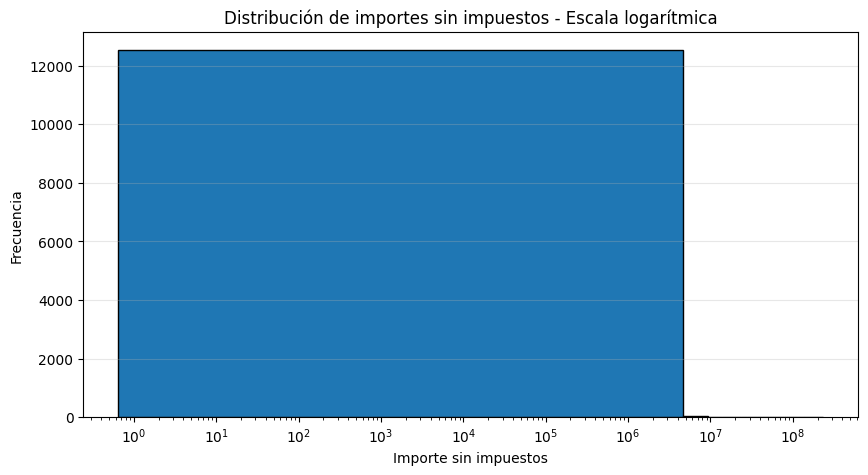

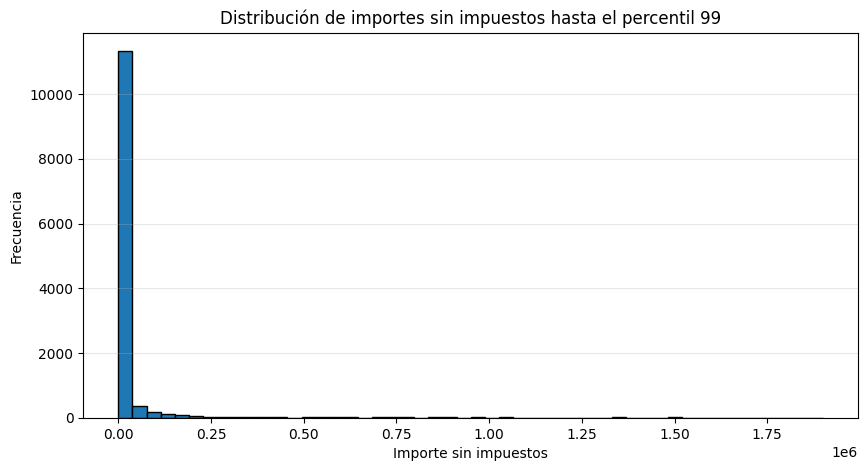

In [246]:
import matplotlib.pyplot as plt
import seaborn as sns

# ===============================
# 1. Preparar variable de importes
# ===============================

importes = df_eda["importe_sin_impuestos"].dropna()

# Opcional: eliminar importes negativos si existieran
importes = importes[importes >= 0]

# Percentil 99 para controlar valores extremos
p99 = importes.quantile(0.99)

importes_p99 = importes[importes <= p99]


# ===============================
# 2. Histograma con escala logarítmica
# ===============================

plt.figure(figsize=(10, 5))

plt.hist(
    importes,
    bins=50,
    edgecolor="black"
)

plt.xscale("log")

plt.title("Distribución de importes sin impuestos - Escala logarítmica")
plt.xlabel("Importe sin impuestos")
plt.ylabel("Frecuencia")

plt.grid(axis="y", alpha=0.3)

plt.show()


# ===============================
# 3. Histograma recortado al percentil 99
# ===============================

plt.figure(figsize=(10, 5))

plt.hist(
    importes_p99,
    bins=50,
    edgecolor="black"
)

plt.title("Distribución de importes sin impuestos hasta el percentil 99")
plt.xlabel("Importe sin impuestos")
plt.ylabel("Frecuencia")

plt.grid(axis="y", alpha=0.3)

plt.show()

La distribución de los importes evidencia una fuerte concentración de licitaciones en valores económicos bajos y medianos, acompañada por una cola derecha extremadamente extensa. Visualmente, el histograma muestra una asimetría positiva severa, donde la gran mayoría de procedimientos se acumula cerca de los valores inferiores, mientras que un número reducido de licitaciones alcanza importes considerablemente superiores.

Este comportamiento es consistente con los resultados observados previamente en los percentiles y en la diferencia existente entre la media y la mediana. Las licitaciones de gran magnitud económica actúan como valores atípicos extremos que expanden significativamente la escala de la distribución y comprimen visualmente la mayor parte de las observaciones cerca del origen. Como consecuencia, la estructura económica del conjunto de oportunidades compatibles con Clínica Los Tilos no puede interpretarse adecuadamente utilizando únicamente escalas lineales o medidas tradicionales de tendencia central.

Desde una perspectiva metodológica, esta distribución sugiere que las licitaciones filtradas mediante los códigos CPV seleccionados no presentan un comportamiento homogéneo, sino una estructura económica compuesta por múltiples escalas de contratación coexistiendo simultáneamente. En términos prácticos, las licitaciones de bajo importe probablemente responden a dinámicas operativas, técnicas y competitivas diferentes a las observadas en procedimientos de gran magnitud económica.

Adicionalmente, la presencia de una cola derecha pronunciada y de valores extremos justifica la necesidad de incorporar transformaciones logarítmicas y técnicas robustas de segmentación en las siguientes etapas analíticas. Estas metodologías permiten reducir el efecto distorsionador de las licitaciones atípicas y facilitan una interpretación más precisa de la estructura distributiva de las oportunidades licitatorias analizadas.

En conjunto, los resultados evidencian que el valor económico de las licitaciones potencialmente aplicables a Clínica Los Tilos no se distribuye de manera uniforme, sino que presenta una elevada concentración en un subconjunto reducido de procedimientos de gran magnitud económica, comportamiento característico de mercados complejos con alta heterogeneidad distributiva.

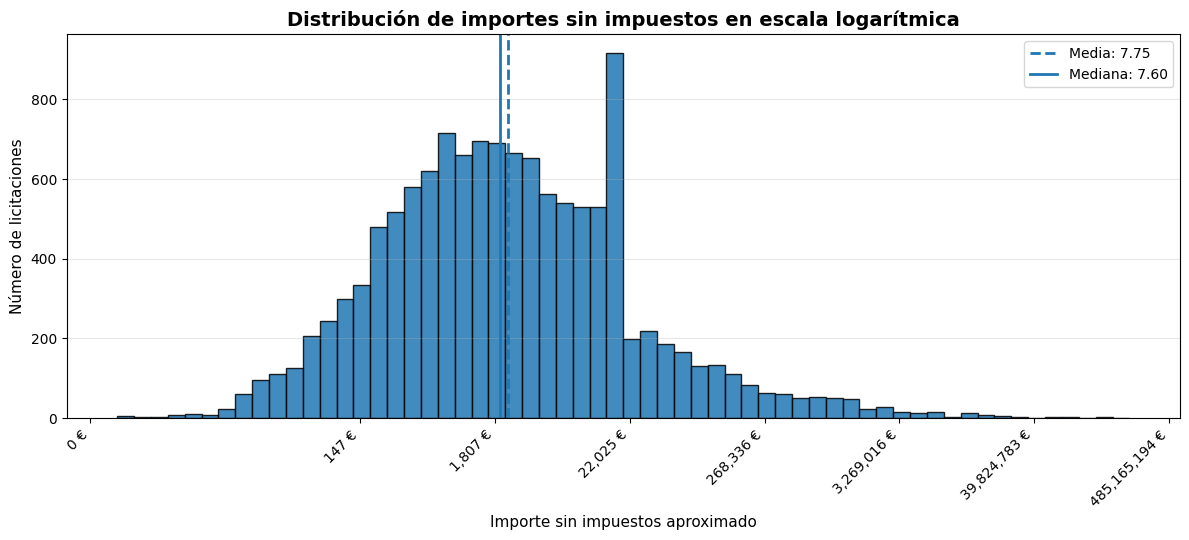

In [248]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Variable logarítmica
# ===============================

df_eda["importe_log"] = np.log1p(df_eda["importe_sin_impuestos"])

importes_log = df_eda["importe_log"].dropna()

# ===============================
# 2. Histograma mejorado
# ===============================

plt.figure(figsize=(12, 5.5))

plt.hist(
    importes_log,
    bins=60,
    edgecolor="black",
    alpha=0.85
)

# Líneas de referencia
media_log = importes_log.mean()
mediana_log = importes_log.median()

plt.axvline(
    media_log,
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_log:.2f}"
)

plt.axvline(
    mediana_log,
    linestyle="-",
    linewidth=2,
    label=f"Mediana: {mediana_log:.2f}"
)

# Marcas del eje X en escala logarítmica con referencia en euros
ticks_log = [0, 5, 7.5, 10, 12.5, 15, 17.5, 20]
labels_euros = [f"{np.expm1(x):,.0f} €" for x in ticks_log]

plt.xticks(
    ticks_log,
    labels_euros,
    rotation=45,
    ha="right"
)

plt.title(
    "Distribución de importes sin impuestos en escala logarítmica",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Importe sin impuestos aproximado", fontsize=11)
plt.ylabel("Número de licitaciones", fontsize=11)

plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

La transformación logarítmica permitió reducir significativamente el efecto de los valores extremos y visualizar de manera más clara la estructura subyacente de la distribución económica de las licitaciones filtradas para Clínica Los Tilos. A diferencia del histograma original, donde las licitaciones de gran magnitud comprimían visualmente la mayoría de observaciones cerca del origen, la escala logarítmica genera una distribución considerablemente más extendida y analíticamente interpretable.

Este comportamiento sugiere que la distribución de los importes dentro del conjunto de oportunidades compatibles con los códigos CPV seleccionados responde a dinámicas económicas de carácter multiplicativo, patrón frecuentemente observado en mercados complejos donde coexisten procedimientos de contratación de muy distinta magnitud económica. La transformación permite evidenciar que el universo analizado no está compuesto únicamente por licitaciones pequeñas acompañadas de algunos valores atípicos aislados, sino por múltiples escalas económicas intermedias distribuidas de forma continua.

Desde una perspectiva metodológica, este resultado resulta especialmente relevante para las siguientes etapas analíticas del proyecto, ya que justifica el uso de transformaciones logarítmicas, segmentaciones distributivas y técnicas robustas de análisis estadístico. La reducción del efecto distorsionador de las licitaciones de importe extremadamente elevado facilita comparaciones más estables entre procedimientos y mejora la interpretabilidad de futuras técnicas de clasificación, clustering y segmentación económica.

Adicionalmente, los resultados sugieren que las comparaciones entre licitaciones no deberían realizarse exclusivamente sobre valores monetarios absolutos, sino sobre escalas normalizadas o segmentadas por percentiles, evitando que los procedimientos de gran magnitud económica dominen completamente el comportamiento agregado de la distribución.

Desde una perspectiva estratégica, la coexistencia de múltiples escalas económicas dentro del conjunto de licitaciones potencialmente aplicables a Clínica Los Tilos refuerza la necesidad de desarrollar un sistema de priorización capaz de diferenciar oportunidades según su tamaño económico y nivel de complejidad operativa. Esto implica que la clínica podría identificar segmentos específicos del mercado donde sus capacidades técnicas, médicas y administrativas presenten una mayor compatibilidad competitiva, en lugar de abordar el ecosistema licitatorio como un conjunto homogéneo de oportunidades.

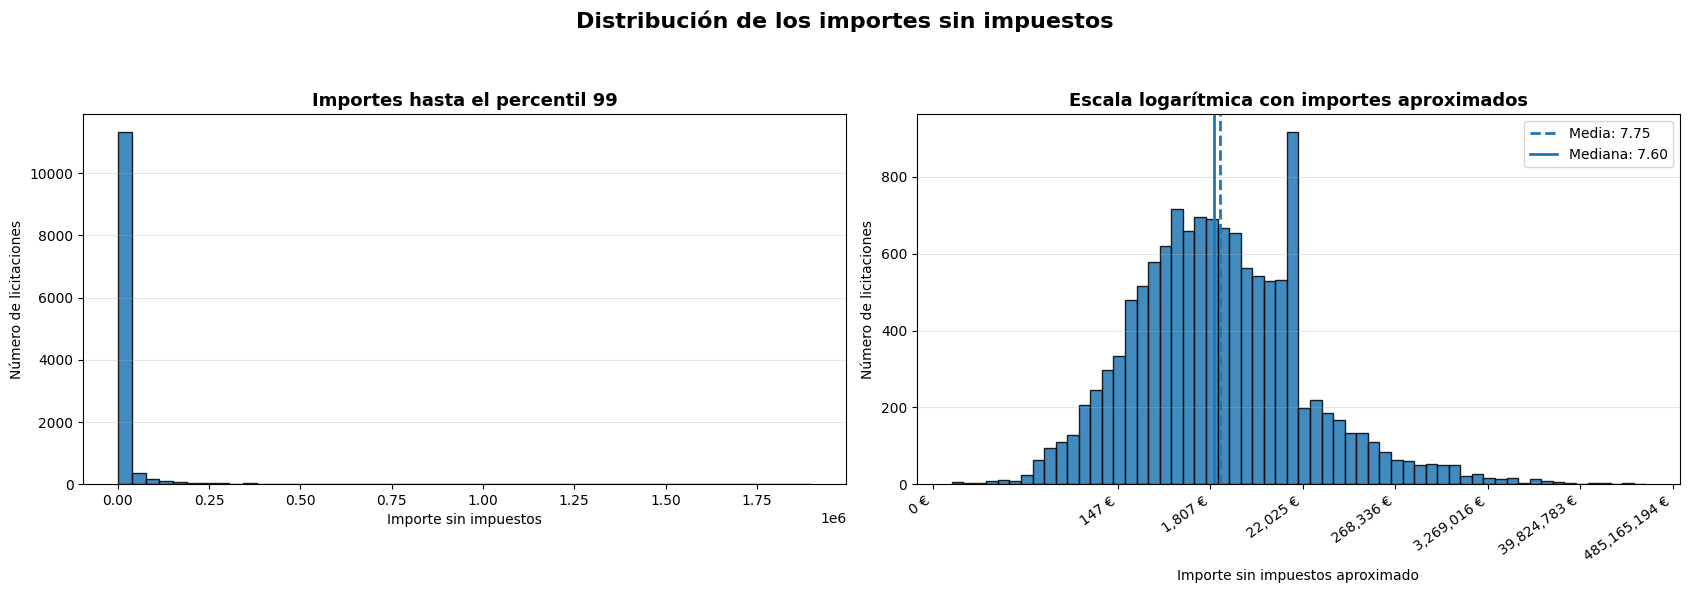

In [249]:
import numpy as np
import matplotlib.pyplot as plt

# ===============================
# 1. Preparar datos
# ===============================

importes = df_eda["importe_sin_impuestos"].dropna()
importes = importes[importes >= 0]

# Percentil 99
p99 = importes.quantile(0.99)
importes_p99 = importes[importes <= p99]

# Escala logarítmica
importe_log = np.log1p(importes)

media_log = importe_log.mean()
mediana_log = importe_log.median()

# ===============================
# 2. Crear figura conjunta
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

fig.suptitle(
    "Distribución de los importes sin impuestos",
    fontsize=16,
    fontweight="bold"
)

# ===============================
# Gráfico 1: percentil 99
# ===============================

axes[0].hist(
    importes_p99,
    bins=50,
    edgecolor="black",
    alpha=0.85
)

axes[0].set_title(
    "Importes hasta el percentil 99",
    fontsize=13,
    fontweight="bold"
)

axes[0].set_xlabel("Importe sin impuestos")
axes[0].set_ylabel("Número de licitaciones")
axes[0].grid(axis="y", alpha=0.3)

# ===============================
# Gráfico 2: escala logarítmica con eje en euros
# ===============================

axes[1].hist(
    importe_log,
    bins=60,
    edgecolor="black",
    alpha=0.85
)

axes[1].axvline(
    media_log,
    linestyle="--",
    linewidth=2,
    label=f"Media: {media_log:.2f}"
)

axes[1].axvline(
    mediana_log,
    linestyle="-",
    linewidth=2,
    label=f"Mediana: {mediana_log:.2f}"
)

ticks_log = [0, 5, 7.5, 10, 12.5, 15, 17.5, 20]
labels_euros = [f"{np.expm1(x):,.0f} €" for x in ticks_log]

axes[1].set_xticks(ticks_log)
axes[1].set_xticklabels(
    labels_euros,
    rotation=35,
    ha="right"
)

axes[1].set_title(
    "Escala logarítmica con importes aproximados",
    fontsize=13,
    fontweight="bold"
)

axes[1].set_xlabel("Importe sin impuestos aproximado")
axes[1].set_ylabel("Número de licitaciones")
axes[1].grid(axis="y", alpha=0.3)
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [143]:
asimetria = skew(df_eda["importe_sin_impuestos"].dropna())

curtosis = kurtosis(df_eda["importe_sin_impuestos"].dropna())

print("Asimetría:", asimetria)
print("Curtosis:", curtosis)

Asimetría: 43.74736845199147
Curtosis: 2343.815045365335


In [144]:
asimetria_log = skew(df_eda["importe_log"].dropna())

curtosis_log = kurtosis(df_eda["importe_log"].dropna())

print("Asimetría log:", asimetria_log)
print("Curtosis log:", curtosis_log)

Asimetría log: 0.5473521019626192
Curtosis log: 0.8910460295652509


El análisis estadístico de la variable importe_sin_impuestos evidencia que el conjunto de licitaciones potencialmente aplicables a Clínica Los Tilos presenta una estructura económica extremadamente desigual y heterogénea. La distribución original mostró una asimetría positiva severa (43,75), indicando que la mayor parte de las licitaciones se concentra en importes relativamente bajos y medianos, mientras que un número reducido de procedimientos alcanza magnitudes económicas excepcionalmente elevadas. Este comportamiento confirma la existencia de una cola derecha extremadamente extensa, característica frecuente en distribuciones económicas complejas donde una pequeña proporción de licitaciones concentra una parte significativa del valor total observado.

Adicionalmente, la curtosis obtenida (2343,82) evidencia una presencia extremadamente elevada de valores atípicos y colas pesadas dentro de la distribución. En términos prácticos, esto significa que existen licitaciones de magnitud económica extraordinaria que distorsionan significativamente las medidas tradicionales de tendencia central y dispersión. Como consecuencia, estadísticas sensibles a valores extremos, como la media aritmética y la desviación estándar, no representan adecuadamente el comportamiento típico del conjunto analizado.

Con el objetivo de estabilizar la distribución y mejorar su interpretabilidad analítica, se aplicó una transformación logarítmica sobre los importes. Los resultados posteriores muestran una reducción drástica tanto de la asimetría como de la curtosis. La asimetría pasó de 43,75 a aproximadamente 0,55, mientras que la curtosis disminuyó de 2343,82 a cerca de 0,89. Esto indica que la transformación logró reducir significativamente el efecto distorsionador de las licitaciones de importe extremadamente elevado, generando una distribución considerablemente más estable y adecuada para análisis estadísticos posteriores.

Desde una perspectiva metodológica, estos resultados justifican el uso de escalas logarítmicas, segmentaciones distributivas y técnicas robustas en futuras etapas del proyecto, incluyendo procesos de clustering, segmentación económica y construcción del sistema de scoring. Asimismo, evidencian que las licitaciones compatibles con los códigos CPV seleccionados para Clínica Los Tilos no deben analizarse como un conjunto homogéneo de oportunidades, sino como un ecosistema compuesto por múltiples escalas económicas coexistiendo simultáneamente.

En términos estratégicos, este comportamiento refuerza la necesidad de desarrollar mecanismos de priorización capaces de diferenciar licitaciones según su magnitud económica, ya que las capacidades operativas, financieras y técnicas requeridas para competir en procedimientos de gran escala probablemente difieren sustancialmente de aquellas necesarias para participar en licitaciones pequeñas o medianas.

In [145]:
top_organos = (
    df_eda
    .groupby("organo_contratacion")
    .agg(
        n_licitaciones=("licitacion_id", "count"),
        importe_total_acumulado=("importe_sin_impuestos", "sum"),
        importe_promedio=("importe_sin_impuestos", "mean")
    )
    .sort_values(
        "importe_total_acumulado",
        ascending=False
    )
)

top_organos.head(20)

,n_licitaciones,importe_total_acumulado,importe_promedio
organo_contratacion,,,
Servicio Andaluz de Salud,218,1165892957.39,5348132.832064
Consellería de Sanidade - SERGAS,11752,275838746.62,23471.642837
Servicio Madrileño de Salud,39,178630271.79,4580263.379231
Agencia de Contratación Sanitaria de la Comunidad de Madrid,5,155309134.3,31061826.86
Consejería de Salud y Familias. Secretaría General Técnica,4,103466952.0,25866738.0
Consejería de Salud y Consumo. Secretaría General Técnica,9,67624320.0,7513813.333333
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau,11,48320226.71,4392747.882727
Director Gerente del Servicio Navarro de Salud-Osasunbidea,17,41657225.83,2450425.048824
"Consejería de Sanidad, Presidencia y Emergencias Secretaría General Técnica de Sanidad y Consumo",2,33260627.52,16630313.76


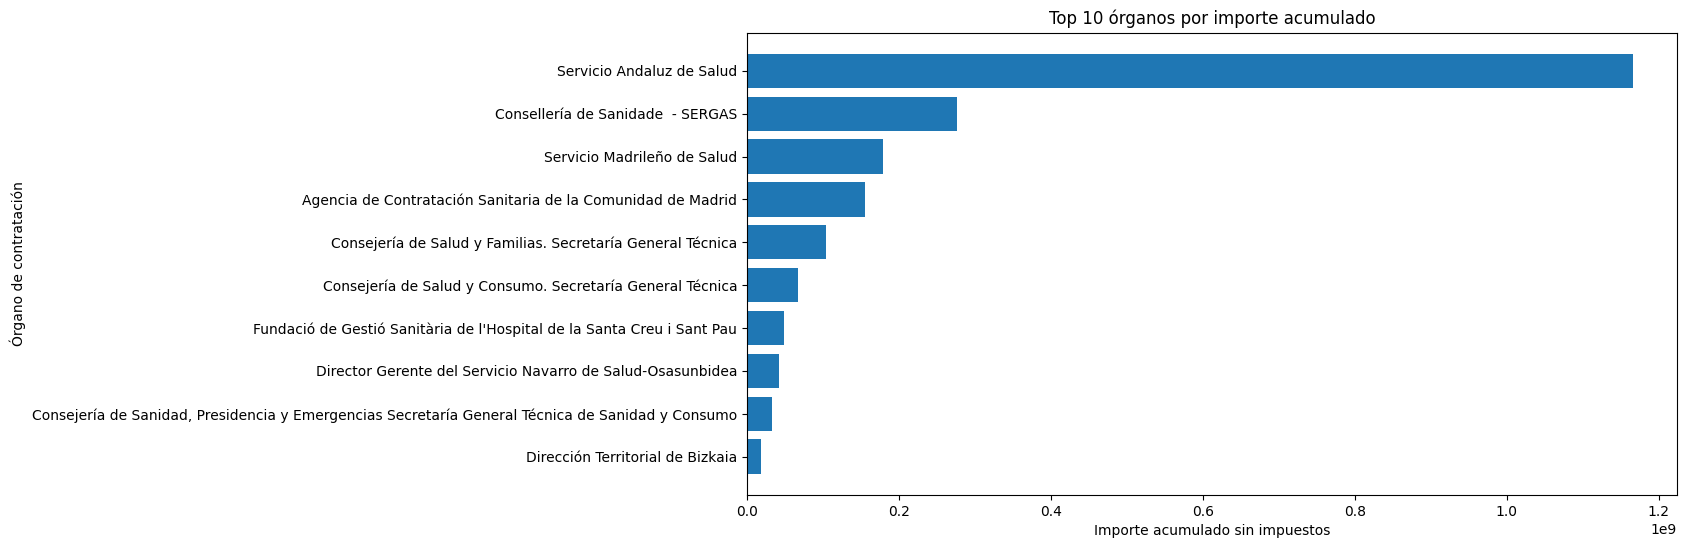

In [146]:
top10 = top_organos.head(10)

plt.figure(figsize=(12,6))

plt.barh(
    top10.index.astype(str),
    top10["importe_total_acumulado"]
)

plt.title("Top 10 órganos por importe acumulado")
plt.xlabel("Importe acumulado sin impuestos")
plt.ylabel("Órgano de contratación")

plt.gca().invert_yaxis()

plt.show()

El análisis de los órganos de contratación evidencia una distribución institucional heterogénea dentro del conjunto de licitaciones filtradas según los códigos CPV compatibles con la actividad de Clínica Los Tilos. Tanto la representación gráfica como los importes acumulados muestran diferencias significativas en el volumen económico gestionado por los distintos organismos públicos presentes en la muestra. En particular, destacan entidades como el Servicio Andaluz de Salud, la Consellería de Sanidade - SERGAS y el Servicio Madrileño de Salud, cuyos importes acumulados superan ampliamente los valores observados en la mayoría de organismos restantes.

La representación gráfica permite identificar una caída pronunciada después de los primeros organismos del ranking, lo que sugiere una elevada concentración institucional del volumen económico analizado. Mientras algunos órganos concentran presupuestos multimillonarios asociados a servicios médicos y sanitarios especializados, el resto presenta volúmenes considerablemente menores. Este comportamiento podría estar asociado tanto a diferencias en capacidad presupuestaria como al tamaño operativo y al alcance territorial de cada sistema sanitario regional o institución pública.

Adicionalmente, se observa que ciertos organismos alcanzan importes acumulados elevados incluso con un número relativamente reducido de licitaciones, lo que sugiere la existencia de procedimientos de gran magnitud económica dentro de áreas específicas del sector salud. Este comportamiento evidencia la coexistencia de distintos perfiles institucionales dentro del ecosistema analizado: organismos con actividad licitatoria intensiva y otros con menor frecuencia de contratación, pero asociados a procedimientos económicamente más grandes o especializados.

Desde una perspectiva analítica, la diferencia entre número de licitaciones, importe acumulado e importe promedio permite identificar distintos patrones de contratación dentro del subconjunto de oportunidades relevantes para Clínica Los Tilos. Mientras algunas entidades concentran volumen económico mediante una actividad licitatoria recurrente, otras participan a través de procedimientos menos frecuentes pero de mayor complejidad económica y operativa.

No obstante, estos resultados deben interpretarse en el contexto del proceso de filtrado aplicado. Los valores observados no representan la totalidad de la contratación sanitaria pública española, sino únicamente las licitaciones asociadas a los códigos CPV seleccionados por su compatibilidad potencial con los servicios médicos, diagnósticos y asistenciales de Clínica Los Tilos. En consecuencia, la estructura institucional observada refleja específicamente el segmento del mercado sanitario donde la clínica podría participar potencialmente.

Desde una perspectiva estratégica, esta heterogeneidad institucional resulta especialmente relevante para el desarrollo del sistema de priorización propuesto en el proyecto. La diferencia en magnitud económica, recurrencia de contratación y perfil institucional entre organismos sugiere que no todas las oportunidades presentan el mismo nivel de accesibilidad para una clínica privada. En este sentido, variables asociadas al órgano contratante podrían constituir componentes relevantes dentro de futuros criterios de scoring y recomendación, permitiendo diferenciar oportunidades según tamaño económico, recurrencia institucional y complejidad operativa del procedimiento.

In [147]:
import numpy as np

def gini(x):

    x = np.array(x, dtype=np.float64)

    # eliminar NA
    x = x[~np.isnan(x)]

    # evitar negativos
    x = x[x >= 0]

    # ordenar
    x = np.sort(x)

    n = len(x)

    indice = np.arange(1, n + 1)

    gini_coef = (
        np.sum((2 * indice - n - 1) * x)
        / (n * np.sum(x))
    )

    return gini_coef

In [148]:
gini_importe = gini(df_eda["importe_sin_impuestos"].dropna())

print(gini_importe)

0.9775443498378837


In [149]:
df_eda["importe_sin_impuestos"].describe(
    percentiles=[0.5, 0.9, 0.95, 0.99, 0.999]
)

count            12589.0
mean       180438.827161
std       3451432.253961
min                 0.65
50%               2000.7
90%              37984.0
95%            139643.66
99%         1901699.8144
99.9%    26885128.963761
max          231886643.5
Name: importe_sin_impuestos, dtype: Float64

In [150]:
df_eda["importe_sin_impuestos"].sort_values(
    ascending=False
).head(20)

12175     231886643.5
12396    161439250.04
12493     139568005.8
252        91241472.0
12211      87439980.0
12171      87439980.0
175       78503448.48
12489     57310857.72
12470      55131601.6
12486     53302237.52
12541      35739600.0
12261      29025000.0
12488     27181525.64
12475     26677449.66
256       26117958.96
12558      22532419.2
12471     22120166.68
12283      22084608.0
12234      21334529.0
201       19424635.05
Name: importe_sin_impuestos, dtype: Float64

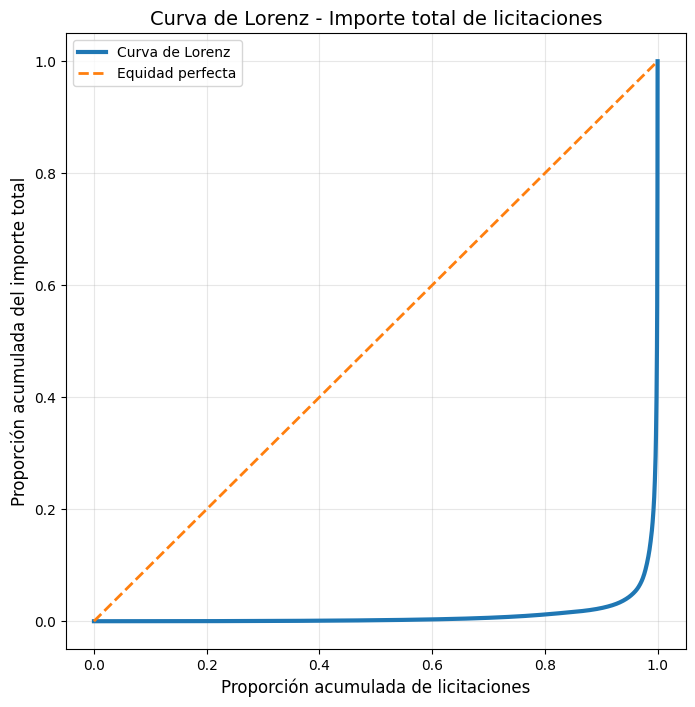

In [151]:
import numpy as np
import matplotlib.pyplot as plt

# limpiar datos
valores = df_eda["importe_sin_impuestos"].dropna()

# mantener positivos
valores = valores[valores >= 0]

# ordenar valores
valores_ordenados = np.sort(valores)

# suma acumulada
acumulado = np.cumsum(valores_ordenados)

# normalizar acumulado
acumulado_normalizado = acumulado / acumulado[-1]

# porcentaje acumulado de licitaciones
proporcion_licitaciones = np.arange(
    1,
    len(valores_ordenados) + 1
) / len(valores_ordenados)

# agregar punto inicial (0,0)
proporcion_licitaciones = np.insert(
    proporcion_licitaciones,
    0,
    0
)

acumulado_normalizado = np.insert(
    acumulado_normalizado,
    0,
    0
)

# gráfica
plt.figure(figsize=(8,8))

plt.plot(
    proporcion_licitaciones,
    acumulado_normalizado,
    linewidth=3,
    label="Curva de Lorenz"
)

# línea de igualdad perfecta
plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    linewidth=2,
    label="Equidad perfecta"
)

plt.title(
    "Curva de Lorenz - Importe total de licitaciones",
    fontsize=14
)

plt.xlabel(
    "Proporción acumulada de licitaciones",
    fontsize=12
)

plt.ylabel(
    "Proporción acumulada del importe total",
    fontsize=12
)

plt.grid(True, alpha=0.3)

plt.legend()

plt.show()

El análisis exploratorio de la variable importe_sin_impuestos evidencia que el conjunto de licitaciones potencialmente aplicables a Clínica Los Tilos presenta una estructura económica extremadamente desigual y altamente concentrada. Para comprender adecuadamente este comportamiento no resultó suficiente utilizar únicamente medidas descriptivas tradicionales como la media o la desviación estándar, sino que fue necesario incorporar métricas especializadas de distribución y concentración económica.

Inicialmente, el análisis descriptivo mostró diferencias muy pronunciadas entre los valores centrales y los extremos de la distribución. Mientras la mediana del importe se sitúa alrededor de 2 mil euros, el percentil 90 supera los 37 mil euros y el percentil 99 alcanza aproximadamente 1,9 millones de euros. Adicionalmente, el percentil 99,9 supera los 26 millones de euros y el valor máximo registrado alcanza aproximadamente 231 millones de euros. Estas diferencias evidencian la existencia de una cola derecha extremadamente extensa y de una estructura distributiva dominada por licitaciones de magnitud económica excepcionalmente elevada.

La asimetría positiva severa observada en la distribución confirma que la mayor parte de las licitaciones se concentra en importes relativamente bajos y medianos, mientras que un subconjunto reducido de procedimientos concentra valores económicos extraordinariamente altos. Complementariamente, la curtosis extremadamente elevada evidencia la presencia de colas pesadas y valores atípicos extremos que distorsionan significativamente las medidas tradicionales de tendencia central y dispersión.

Sin embargo, aunque la asimetría y la curtosis permiten describir la forma estadística de la distribución, estas métricas no cuantifican directamente el nivel de desigualdad económica existente entre las licitaciones. Por esta razón se incorporó el coeficiente de Gini, ampliamente utilizado en economía y análisis de concentración para medir desigualdad distributiva.

El coeficiente de Gini obtenido fue aproximadamente de:

Gini≈0.978

Este valor representa una concentración económica extremadamente elevada, indicando que una proporción muy reducida de licitaciones concentra gran parte del importe económico total observado, mientras que la mayoría de procedimientos participa con una fracción relativamente pequeña del volumen económico agregado.

Con el objetivo de visualizar gráficamente esta desigualdad se construyó la Curva de Lorenz. Esta técnica representa la proporción acumulada de licitaciones frente a la proporción acumulada del importe económico total. La línea diagonal representa un escenario hipotético de igualdad perfecta, donde todas las licitaciones tendrían el mismo peso económico. Sin embargo, la curva observada se aleja de manera muy pronunciada respecto a dicha diagonal, evidenciando una fuerte concentración económica en un subconjunto reducido de procedimientos de gran magnitud.

La utilización conjunta de asimetría, curtosis, coeficiente de Gini y Curva de Lorenz permite caracterizar de manera rigurosa la estructura económica del conjunto de oportunidades analizado. Mientras la asimetría y la curtosis describen la forma estadística de la distribución, el coeficiente de Gini y la Curva de Lorenz cuantifican y visualizan el nivel de concentración económica existente. En conjunto, los resultados confirman que las licitaciones compatibles con los códigos CPV seleccionados para Clínica Los Tilos presentan una estructura distributiva altamente desigual, dominada por procedimientos de gran magnitud económica que condicionan significativamente el comportamiento agregado del conjunto analizado.

Desde la perspectiva del proyecto, este hallazgo resulta especialmente relevante, ya que justifica la necesidad de desarrollar mecanismos de priorización y análisis estratégico de licitaciones. Dado que no todas las oportunidades poseen el mismo impacto económico potencial, la elevada concentración observada respalda la implementación de sistemas de scoring y clasificación capaces de diferenciar procedimientos según su relevancia económica, complejidad operativa y potencial estratégico para Clínica Los Tilos.

In [152]:
participacion_organos = (
    df_eda
    .groupby("organo_contratacion")[
        "importe_sin_impuestos"
    ]
    .sum()
)

participacion_organos = (
    participacion_organos
    / participacion_organos.sum()
)

In [153]:
hhi = np.sum(participacion_organos ** 2)

print("HHI institucional:", hhi)

HHI institucional: 0.293277121215076


In [154]:
hhi_10000 = hhi * 10000

print("HHI (0-10000):", hhi_10000)

HHI (0-10000): 2932.7712121507598


Con el objetivo de complementar el análisis de desigualdad económica, se calculó el índice Herfindahl-Hirschman (HHI) sobre la distribución del importe acumulado gestionado por los distintos órganos de contratación presentes dentro del conjunto de licitaciones compatibles con los códigos CPV seleccionados para Clínica Los Tilos. Esta métrica permite evaluar el nivel de concentración institucional del mercado, considerando la participación relativa de cada organismo dentro del volumen económico total analizado.

El valor obtenido fue aproximadamente de 0,2933, equivalente a 2933 puntos en la escala tradicional utilizada en análisis de competencia económica.

Este resultado sugiere que el subconjunto de licitaciones analizado presenta un nivel de concentración institucional elevado. Aunque existen múltiples organismos públicos participando dentro del ecosistema licitatorio filtrado, una proporción importante del volumen económico total se concentra en un número reducido de entidades contratantes, entre las que destacan organismos como el Servicio Andaluz de Salud, el Servicio Madrileño de Salud y la Consellería de Sanidade - SERGAS.

La diferencia observada entre el coeficiente de Gini y el índice HHI resulta especialmente relevante desde una perspectiva analítica. Mientras el coeficiente de Gini evidenció una desigualdad económica extremadamente elevada entre licitaciones individuales, el HHI muestra que parte de esta concentración también se encuentra asociada a determinados organismos públicos con alta capacidad presupuestaria y elevada actividad contractual dentro del segmento sanitario analizado.

En otras palabras, las licitaciones compatibles con los servicios potencialmente ofertados por Clínica Los Tilos no solo presentan procedimientos económicamente muy desiguales, sino también una estructura institucional relativamente concentrada, donde ciertos organismos concentran una fracción considerable del volumen económico total observado.

Desde una perspectiva estratégica, este hallazgo tiene implicaciones relevantes para el desarrollo del sistema de priorización propuesto en el proyecto. La elevada concentración institucional sugiere que algunos organismos podrían representar actores estratégicos prioritarios dentro del ecosistema de contratación pública sanitaria compatible con la clínica. En consecuencia, variables asociadas al órgano contratante podrían convertirse en componentes relevantes dentro de futuros mecanismos de scoring y recomendación, permitiendo diferenciar oportunidades según recurrencia institucional, tamaño económico y nivel potencial de competencia asociado a cada entidad pública.

In [155]:
percentiles = df_eda["importe_sin_impuestos"].quantile(
    [0.25, 0.50, 0.75, 0.95, 0.99]
)

p25 = percentiles[0.25]
p50 = percentiles[0.50]
p75 = percentiles[0.75]
p95 = percentiles[0.95]
p99 = percentiles[0.99]

In [156]:
def clasificar_tamano(x):

    if pd.isna(x):
        return np.nan

    elif x <= p25:
        return "Muy pequeña"

    elif x <= p50:
        return "Pequeña"

    elif x <= p75:
        return "Mediana"

    elif x <= p95:
        return "Grande"

    elif x <= p99:
        return "Muy grande"

    else:
        return "Macrolicitación"

df_eda["tamano_licitacion"] = (
    df_eda["importe_sin_impuestos"]
    .apply(clasificar_tamano)
)

In [157]:
tamano_resumen = (
    df_eda
    .groupby("tamano_licitacion")
    .agg(
        n_licitaciones=("licitacion_id", "count"),
        importe_total=("importe_sin_impuestos", "sum"),
        importe_promedio=("importe_sin_impuestos", "mean")
    )
)

tamano_resumen

,n_licitaciones,importe_total,importe_promedio
tamano_licitacion,,,
Grande,2517,80187985.65,31858.556079
Macrolicitación,126,1900764299.81,15085430.950873
Mediana,3146,15345606.98,4877.815315
Muy grande,504,271260679.04,538215.633016
Muy pequeña,3148,625870.07,198.815143
Pequeña,3148,3359953.58,1067.3296


<Axes: xlabel='tamano_licitacion'>

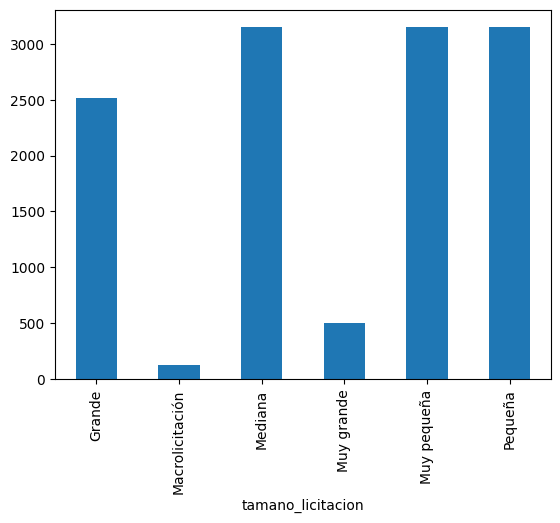

In [158]:
tamano_resumen["n_licitaciones"].plot(
    kind="bar"
)

<Axes: xlabel='tamano_licitacion'>

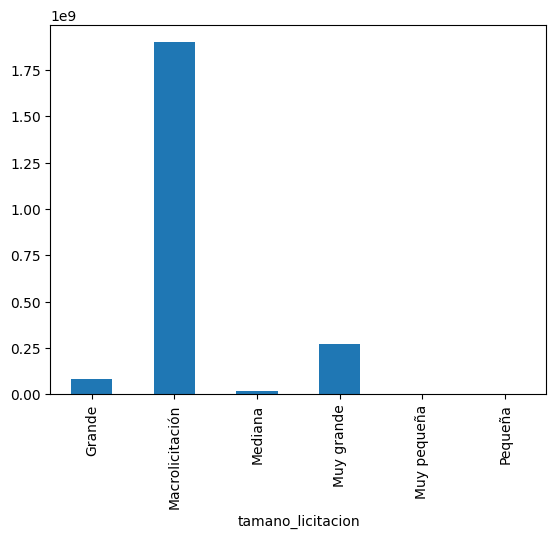

In [159]:
tamano_resumen["importe_total"].plot(
    kind="bar"
)

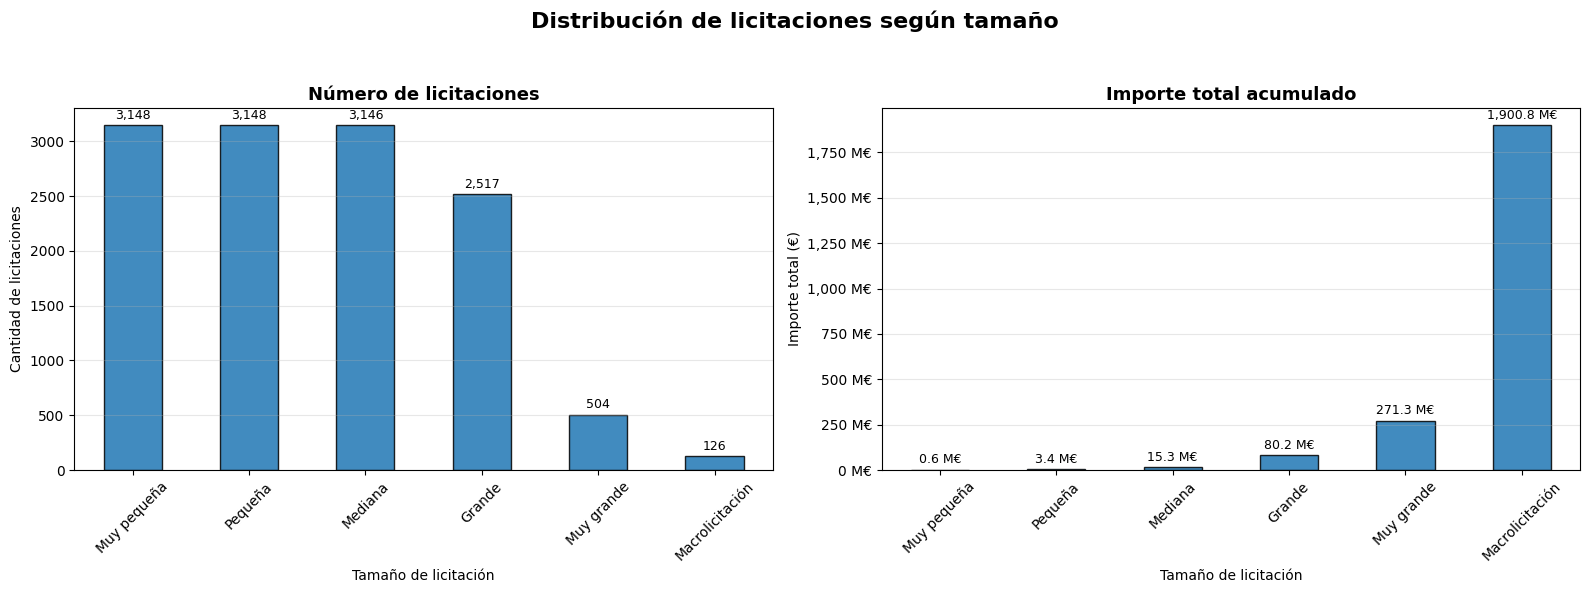

In [250]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

# ===============================
# 1. Preparar tabla
# ===============================

if "tamano_licitacion" in tamano_resumen.columns:
    tamano_plot = tamano_resumen.set_index("tamano_licitacion").copy()
else:
    tamano_plot = tamano_resumen.copy()

# Orden lógico de categorías
orden = ["Muy pequeña", "Pequeña", "Mediana", "Grande", "Muy grande", "Macrolicitación"]

# Reordenar solo con las categorías que existan
orden_existente = [x for x in orden if x in tamano_plot.index]
tamano_plot = tamano_plot.reindex(orden_existente)

# ===============================
# 2. Crear figura conjunta
# ===============================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Distribución de licitaciones según tamaño",
    fontsize=16,
    fontweight="bold"
)

# ===============================
# 3. Gráfico 1: número de licitaciones
# ===============================

tamano_plot["n_licitaciones"].plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black",
    alpha=0.85
)

axes[0].set_title("Número de licitaciones", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tamaño de licitación")
axes[0].set_ylabel("Cantidad de licitaciones")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

# Etiquetas sobre barras
for i, v in enumerate(tamano_plot["n_licitaciones"]):
    axes[0].text(i, v + max(tamano_plot["n_licitaciones"]) * 0.01, f"{int(v):,}", 
                 ha="center", va="bottom", fontsize=9)

# ===============================
# 4. Gráfico 2: importe total
# ===============================

tamano_plot["importe_total"].plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black",
    alpha=0.85
)

axes[1].set_title("Importe total acumulado", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tamaño de licitación")
axes[1].set_ylabel("Importe total (€)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

# Formato del eje Y en millones de euros
axes[1].yaxis.set_major_formatter(FuncFormatter(lambda x, pos: f"{x/1e6:,.0f} M€"))

# Etiquetas sobre barras
for i, v in enumerate(tamano_plot["importe_total"]):
    axes[1].text(i, v + max(tamano_plot["importe_total"]) * 0.01, f"{v/1e6:,.1f} M€", 
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

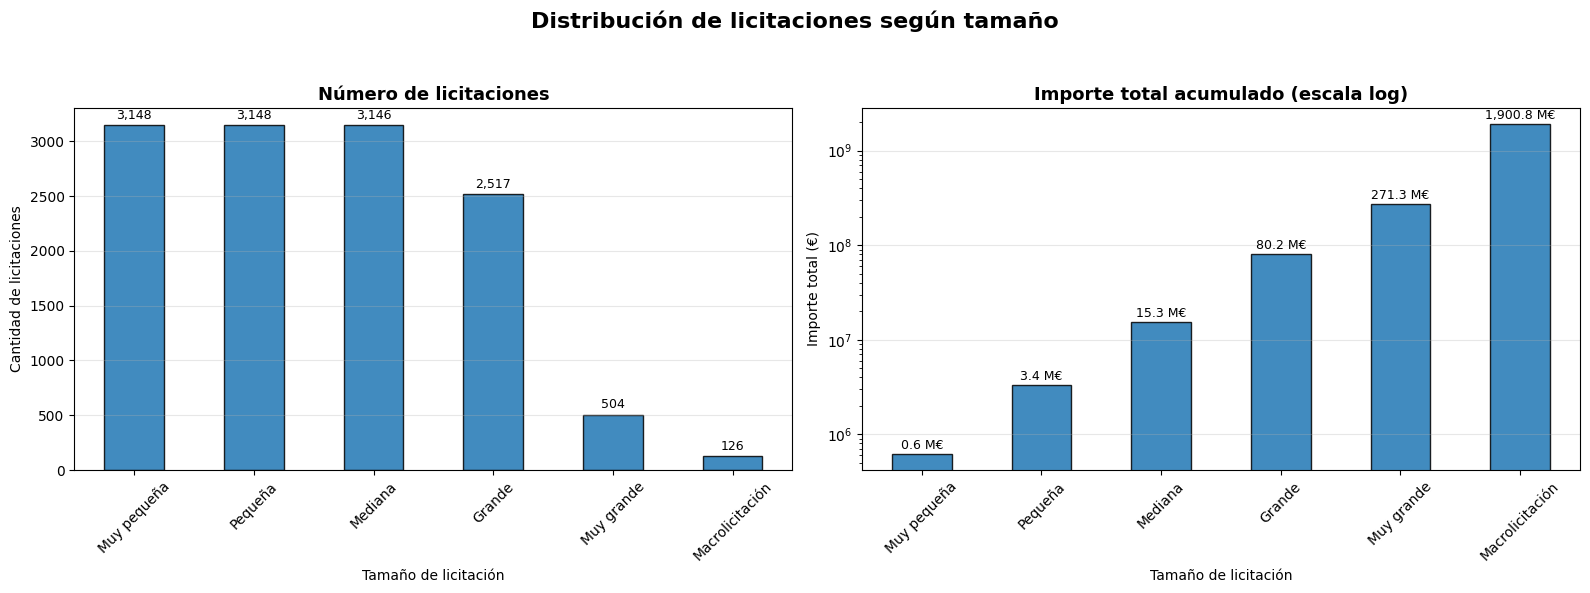

In [251]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

if "tamano_licitacion" in tamano_resumen.columns:
    tamano_plot = tamano_resumen.set_index("tamano_licitacion").copy()
else:
    tamano_plot = tamano_resumen.copy()

orden = ["Muy pequeña", "Pequeña", "Mediana", "Grande", "Muy grande", "Macrolicitación"]
orden_existente = [x for x in orden if x in tamano_plot.index]
tamano_plot = tamano_plot.reindex(orden_existente)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

fig.suptitle(
    "Distribución de licitaciones según tamaño",
    fontsize=16,
    fontweight="bold"
)

# Número de licitaciones
tamano_plot["n_licitaciones"].plot(
    kind="bar",
    ax=axes[0],
    edgecolor="black",
    alpha=0.85
)
axes[0].set_title("Número de licitaciones", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Tamaño de licitación")
axes[0].set_ylabel("Cantidad de licitaciones")
axes[0].tick_params(axis="x", rotation=45)
axes[0].grid(axis="y", alpha=0.3)

for i, v in enumerate(tamano_plot["n_licitaciones"]):
    axes[0].text(i, v + max(tamano_plot["n_licitaciones"]) * 0.01, f"{int(v):,}",
                 ha="center", va="bottom", fontsize=9)

# Importe total en log
tamano_plot["importe_total"].plot(
    kind="bar",
    ax=axes[1],
    edgecolor="black",
    alpha=0.85
)
axes[1].set_yscale("log")
axes[1].set_title("Importe total acumulado (escala log)", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Tamaño de licitación")
axes[1].set_ylabel("Importe total (€)")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", alpha=0.3)

for i, v in enumerate(tamano_plot["importe_total"]):
    axes[1].text(i, v * 1.05, f"{v/1e6:,.1f} M€",
                 ha="center", va="bottom", fontsize=9)

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Interpretación de la segmentación por tamaños de licitación

Con el objetivo de caracterizar la estructura económica del conjunto de licitaciones compatibles con los códigos CPV seleccionados para Clínica Los Tilos, se realizó una segmentación de los procedimientos según percentiles distributivos del importe_sin_impuestos. Esta clasificación permitió identificar distintos grupos de licitaciones en función de su magnitud económica relativa, diferenciando entre procedimientos muy pequeños, pequeños, medianos, grandes, muy grandes y macrolicitaciones.

Los resultados muestran que la distribución del número de licitaciones es relativamente equilibrada entre las categorías centrales de la segmentación, especialmente en los grupos de licitaciones muy pequeñas, pequeñas y medianas, cada uno con aproximadamente 3.100 procedimientos. Por el contrario, las categorías de mayor magnitud económica presentan una frecuencia considerablemente menor. En particular, las macrolicitaciones representan únicamente 126 procedimientos dentro de las más de 12 mil licitaciones analizadas.

No obstante, al analizar el importe económico acumulado por segmento, se observa un comportamiento radicalmente distinto. A pesar de su baja frecuencia relativa, las macrolicitaciones concentran el mayor volumen económico agregado del conjunto analizado, acumulando aproximadamente 1.900 millones de euros. Este valor supera ampliamente los importes acumulados observados en categorías con miles de procedimientos adicionales. De manera similar, las licitaciones clasificadas como muy grandes también concentran una proporción significativa del volumen económico total, superando los 271 millones de euros acumulados.

Este comportamiento confirma nuevamente la existencia de una estructura económica altamente desigual y concentrada dentro del subconjunto de oportunidades potencialmente aplicables a Clínica Los Tilos. Una pequeña cantidad de procedimientos de gran magnitud económica domina gran parte del volumen financiero total, mientras que la mayoría de licitaciones se concentra en segmentos de bajo y mediano importe.

Desde una perspectiva analítica, la diferencia observada entre frecuencia e importe acumulado evidencia que la relevancia estratégica de una licitación no depende únicamente de la cantidad de procedimientos existentes dentro de una categoría, sino también de la magnitud económica asociada a cada segmento. En términos prácticos, mientras las licitaciones pequeñas y medianas representan la mayor parte de la actividad licitatoria en términos de frecuencia, las macrolicitaciones poseen un peso desproporcionadamente alto sobre el comportamiento económico agregado del ecosistema analizado.

Adicionalmente, el análisis del importe promedio por segmento permite evidenciar diferencias sustanciales entre categorías. Mientras las licitaciones muy pequeñas presentan importes promedio inferiores a 200 euros y las pequeñas rondan los 1.000 euros, las macrolicitaciones alcanzan promedios superiores a 15 millones de euros por procedimiento. Esto evidencia la coexistencia de múltiples escalas económicas y operativas dentro del conjunto de oportunidades filtradas para la clínica.

Desde la perspectiva del proyecto, este hallazgo resulta especialmente relevante para el desarrollo del sistema de priorización y scoring. La coexistencia de múltiples escalas económicas sugiere que las oportunidades de contratación pública no deben evaluarse de forma homogénea, sino considerando variables como tamaño económico, complejidad operativa, requisitos técnicos y capacidad institucional necesaria para competir en cada segmento del mercado.

En conjunto, los resultados refuerzan la necesidad de incorporar segmentaciones económicas dentro de futuros mecanismos de recomendación y análisis estratégico, permitiendo diferenciar oportunidades según su perfil económico y su nivel potencial de compatibilidad con las capacidades operativas de Clínica Los Tilos.

### Conclusiones generales — Bloque 1: Caracterización económica e institucional de las licitaciones

El análisis exploratorio realizado sobre las licitaciones filtradas mediante los códigos CPV compatibles con los servicios potencialmente ofertados por Clínica Los Tilos permitió identificar una estructura económica e institucional altamente heterogénea dentro del ecosistema de contratación pública sanitaria analizado.

En primer lugar, la base consolidada mostró un volumen suficientemente amplio y estructuralmente consistente para el desarrollo del proyecto, conformado por más de 12 mil licitaciones únicas provenientes de 230 órganos de contratación distintos y asociadas a 35 códigos CPV estratégicamente seleccionados. Este filtrado permitió enfocar el análisis exclusivamente en oportunidades potencialmente relevantes para la clínica, evitando incorporar procedimientos ajenos a su capacidad operativa o perfil asistencial.

Desde la perspectiva económica, los resultados evidenciaron una distribución extremadamente desigual de los importes licitatorios. La elevada diferencia entre media y mediana, junto con los altos niveles de asimetría, curtosis y concentración económica, demostraron que el conjunto analizado se encuentra dominado por un número reducido de procedimientos de gran magnitud económica. Esta estructura distributiva fue confirmada mediante métricas robustas como el coeficiente de Gini y la Curva de Lorenz, las cuales evidenciaron niveles extremos de concentración del volumen económico acumulado.

La transformación logarítmica aplicada sobre los importes permitió estabilizar parcialmente la distribución y evidenció la coexistencia de múltiples escalas económicas dentro del mercado analizado. Este comportamiento confirmó que las oportunidades licitatorias no constituyen un conjunto homogéneo de procedimientos comparables entre sí, sino un ecosistema compuesto por segmentos económicos con dinámicas operativas y competitivas distintas.

Adicionalmente, el análisis institucional mostró que parte importante del volumen económico se concentra en un subconjunto reducido de organismos públicos con elevada capacidad presupuestaria y alta actividad contractual. El índice Herfindahl-Hirschman evidenció un nivel relevante de concentración institucional, aunque sin llegar a un escenario completamente monopolizado por un único organismo contratante. Este hallazgo sugiere la existencia de entidades estratégicas prioritarias dentro del ecosistema licitatorio compatible con Clínica Los Tilos.

Por otra parte, la segmentación económica por tamaños de licitación permitió identificar que las macrolicitaciones, pese a representar una proporción mínima del número total de procedimientos, concentran una parte desproporcionadamente alta del importe económico agregado. En contraste, las licitaciones pequeñas y medianas constituyen la mayor parte de la actividad licitatoria en términos de frecuencia. Esta diferencia confirma que la relevancia estratégica de una licitación no depende únicamente de su ocurrencia, sino también de su magnitud económica y de las capacidades requeridas para competir en cada segmento.

En conjunto, los resultados del bloque evidencian que el ecosistema de contratación pública sanitaria compatible con Clínica Los Tilos presenta altos niveles de complejidad distributiva, concentración económica y heterogeneidad institucional. Estos hallazgos justifican metodológicamente la necesidad de desarrollar mecanismos de priorización, segmentación y scoring capaces de diferenciar oportunidades según variables económicas, institucionales y operativas.

Finalmente, este bloque permitió establecer las bases analíticas necesarias para las siguientes etapas del proyecto, proporcionando una comprensión estructural del comportamiento económico del mercado licitatorio y justificando el uso de metodologías robustas de análisis, segmentación y recomendación estratégica de oportunidades públicas.

# Segundo bloque

## Bloque 2 — Estructura funcional de las oportunidades licitatorias

- ¿Qué categorías CPV concentran la mayor parte de las oportunidades compatibles con Clínica Los Tilos?
- ¿Qué categorías CPV acumulan el mayor volumen económico dentro del mercado analizado?
- ¿Existen diferencias significativas en el tamaño económico de las licitaciones según la especialidad sanitaria?
- ¿Cómo se distribuyen las oportunidades entre servicios sanitarios generales y servicios médicos especializados?
- ¿Qué categorías funcionales podrían representar segmentos estratégicos de interés para Clínica Los Tilos?

In [160]:
df_eda["tipo_contrato"].value_counts(dropna=False)

tipo_contrato
Obras                     9605
Servicios                 2912
Suministros                 38
Otros / No clasificado      20
Concesion de obras          11
Concesion de servicios       3
Name: count, dtype: int64

In [161]:
cpv_freq = (
    df_eda["cpv_descripcion"]
    .value_counts(dropna=False)
    .reset_index()
)

cpv_freq.columns = [
    "cpv_descripcion",
    "n_licitaciones"
]

cpv_freq["porcentaje"] = (
    cpv_freq["n_licitaciones"]
    / cpv_freq["n_licitaciones"].sum()
) * 100

cpv_freq["porcentaje_acumulado"] = (
    cpv_freq["porcentaje"]
    .cumsum()
)

cpv_freq.head(30)

,cpv_descripcion,n_licitaciones,porcentaje,porcentaje_acumulado
0,Servicios de salud,12049,95.710541,95.710541
1,Servicios varios de salud,91,0.722853,96.433394
2,Servicios prestados por laboratorios médicos,81,0.643419,97.076813
3,Servicios de médicos especialistas,55,0.436889,97.513702
4,Servicios psiquiátricos o psicológicos,47,0.373342,97.887044
5,Servicios ginecológicos u obstétricos,46,0.365398,98.252443
6,Servicios de análisis médicos,41,0.325681,98.578124
7,Servicios de médicos de medicina general,33,0.262134,98.840257
8,Servicios de sanidad de las empresas,33,0.262134,99.102391
9,Servicios prestados por enfermeros,13,0.103265,99.205656


In [162]:
top_10 = cpv_freq.head(10).copy()

top_10["porcentaje"] = (
    top_10["porcentaje"]
    .round(2)
)

top_10

,cpv_descripcion,n_licitaciones,porcentaje,porcentaje_acumulado
0,Servicios de salud,12049,95.71,95.710541
1,Servicios varios de salud,91,0.72,96.433394
2,Servicios prestados por laboratorios médicos,81,0.64,97.076813
3,Servicios de médicos especialistas,55,0.44,97.513702
4,Servicios psiquiátricos o psicológicos,47,0.37,97.887044
5,Servicios ginecológicos u obstétricos,46,0.37,98.252443
6,Servicios de análisis médicos,41,0.33,98.578124
7,Servicios de médicos de medicina general,33,0.26,98.840257
8,Servicios de sanidad de las empresas,33,0.26,99.102391
9,Servicios prestados por enfermeros,13,0.10,99.205656


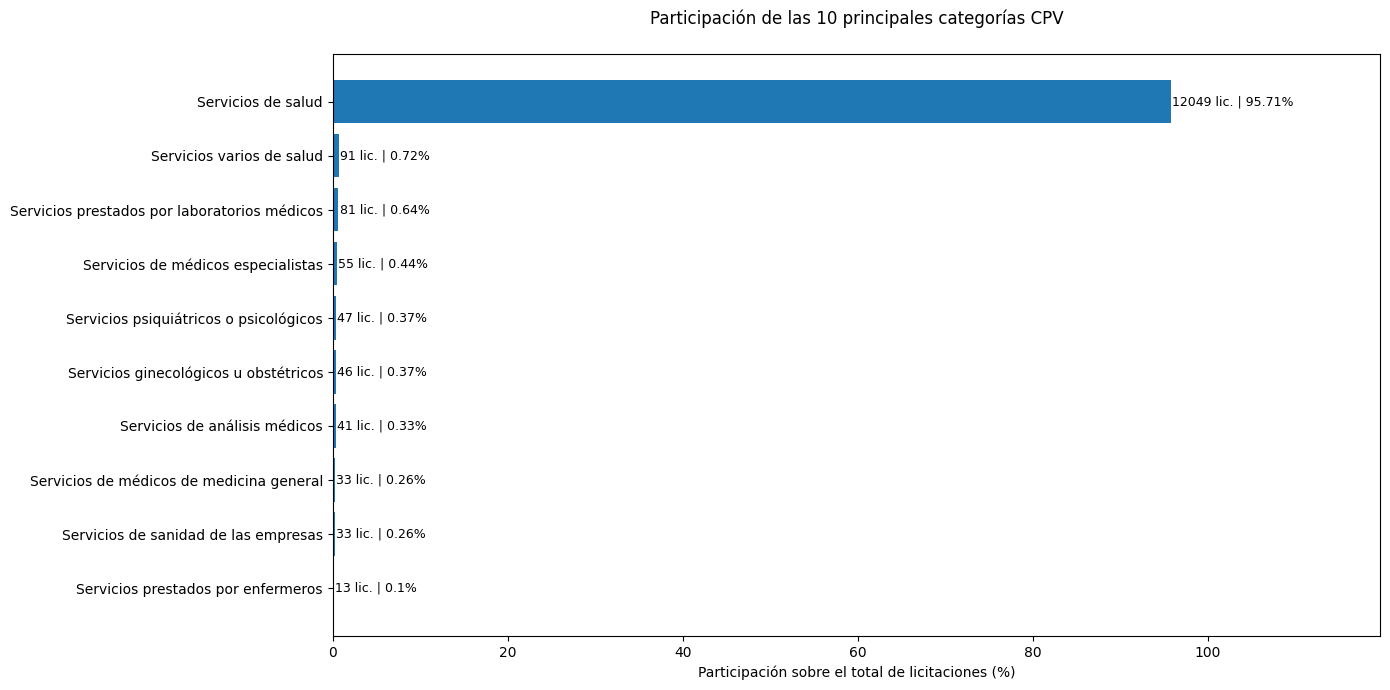

In [163]:
import matplotlib.pyplot as plt

top_10 = cpv_freq.head(10).copy()

total_cpv = len(cpv_freq)

top_10["etiqueta"] = (
    top_10["n_licitaciones"].astype(str)
    + " lic. | "
    + top_10["porcentaje"].round(2).astype(str)
    + "%"
)

fig, ax = plt.subplots(figsize=(14, 7))

bars = ax.barh(
    top_10["cpv_descripcion"][::-1],
    top_10["porcentaje"][::-1]
)

# espacio extra a la derecha para etiquetas
ax.set_xlim(
    0,
    top_10["porcentaje"].max() * 1.25
)

for bar, etiqueta in zip(bars, top_10["etiqueta"][::-1]):

    ax.text(
        bar.get_width() + 0.15,
        bar.get_y() + bar.get_height()/2,
        etiqueta,
        va="center",
        fontsize=9
    )

ax.set_xlabel("Participación sobre el total de licitaciones (%)")
ax.set_ylabel("")

ax.set_title(
    "Participación de las 10 principales categorías CPV\n"
)

plt.tight_layout()

plt.show()

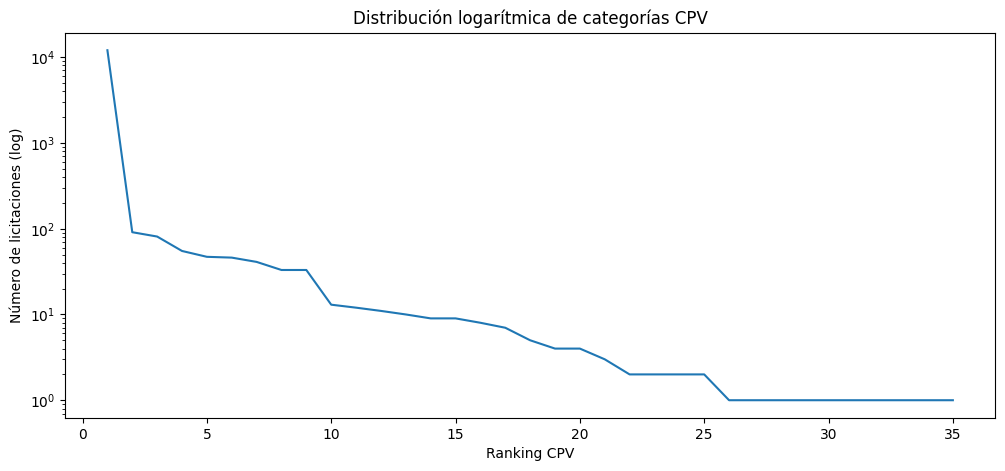

In [164]:
plt.figure(figsize=(12,5))

plt.plot(
    range(1, len(cpv_freq)+1),
    cpv_freq["n_licitaciones"].values
)

plt.yscale("log")

plt.xlabel("Ranking CPV")
plt.ylabel("Número de licitaciones (log)")

plt.title("Distribución logarítmica de categorías CPV")

plt.show()

El análisis de frecuencia de categorías CPV evidencia que el subconjunto de licitaciones compatible con los servicios potencialmente ofertados por Clínica Los Tilos presenta una estructura extremadamente concentrada alrededor de un núcleo funcional específico. A diferencia del mercado sanitario general, donde existe una elevada diversidad temática entre categorías contractuales, el proceso de filtrado aplicado en este proyecto redujo deliberadamente el universo de análisis hacia procedimientos directamente relacionados con servicios médicos, asistenciales y diagnósticos compatibles con la actividad de la clínica.

Los resultados muestran que la categoría “Servicios de salud” concentra aproximadamente el 95,7% de todas las licitaciones analizadas, representando más de 12 mil procedimientos dentro del conjunto filtrado. Este comportamiento evidencia que la mayor parte de las oportunidades identificadas se agrupa bajo una categoría CPV general altamente dominante, mientras que el resto de categorías específicas presentan participaciones considerablemente menores.

Posteriormente aparecen categorías asociadas a servicios varios de salud, laboratorios médicos, médicos especialistas, servicios psiquiátricos o psicológicos, ginecología, análisis médicos y servicios de medicina general. Aunque estas categorías poseen una frecuencia relativamente baja frente al CPV principal, resultan relevantes desde una perspectiva funcional, ya que permiten identificar nichos específicos de actividad sanitaria dentro del ecosistema licitatorio analizado.

La distribución logarítmica de frecuencias evidencia que, después de la categoría dominante, la frecuencia de aparición de los CPV disminuye abruptamente y genera una cola larga compuesta por múltiples categorías altamente especializadas y de baja recurrencia. Este comportamiento sugiere que, aunque el mercado filtrado se encuentra estructuralmente concentrado alrededor de los servicios sanitarios generales, continúan existiendo segmentos técnicos específicos asociados a especialidades médicas, análisis clínicos, enfermería y servicios diagnósticos particulares.

Desde una perspectiva analítica, este resultado refleja directamente el efecto del proceso de selección de códigos CPV utilizado para construir la base del proyecto. La concentración observada no implica necesariamente una baja diversidad funcional del mercado sanitario público, sino que responde al enfoque estratégico de restringir el análisis únicamente a categorías potencialmente compatibles con las capacidades operativas de Clínica Los Tilos.

En términos estratégicos, este hallazgo resulta especialmente relevante para el desarrollo del sistema de priorización propuesto en el TFM. La fuerte concentración en un núcleo reducido de categorías sugiere que la clínica podría focalizar sus mecanismos de monitoreo, análisis y scoring sobre segmentos funcionales altamente específicos del mercado sanitario público. Al mismo tiempo, la presencia de categorías especializadas de menor frecuencia podría representar oportunidades de nicho con menor competencia potencial y mayor alineación técnica con determinadas capacidades asistenciales de la institución.

## Importe sin impuestos

In [165]:
cpv_importe = (
    df_eda
    .groupby("cpv_descripcion", as_index=False)
    .agg(
        n_licitaciones=("licitacion_id", "count"),
        importe_total=("importe_sin_impuestos", "sum"),
        importe_promedio=("importe_sin_impuestos", "mean"),
        importe_mediano=("importe_sin_impuestos", "median")
    )
)

cpv_importe = cpv_importe.sort_values(
    "importe_total",
    ascending=False
)

cpv_importe.head(10)

,cpv_descripcion,n_licitaciones,importe_total,importe_promedio,importe_mediano
19,Servicios de salud,12049,1606976762.12,133370.135457,1778.1
32,Servicios prestados por laboratorios médicos,81,305965963.7,3777357.576543,226994.88
34,Servicios varios de salud,91,134600702.78,1479128.601978,124700.0
28,Servicios ginecológicos u obstétricos,46,63976531.19,1390794.156304,572777.32
33,Servicios psiquiátricos o psicológicos,47,48378167.36,1029322.709787,63750.0
15,Servicios de médicos especialistas,55,36960064.29,672001.168909,175000.0
10,Servicios de imaginería,11,19546289.3,1776935.390909,102375.0
1,Servicios de análisis médicos,41,17653207.78,430566.043415,77000.0
12,Servicios de médicos de medicina general,33,11726782.64,355357.049697,146280.0
16,Servicios de médicos especialistas; Servicios ...,10,5105644.52,510564.452,616944.95


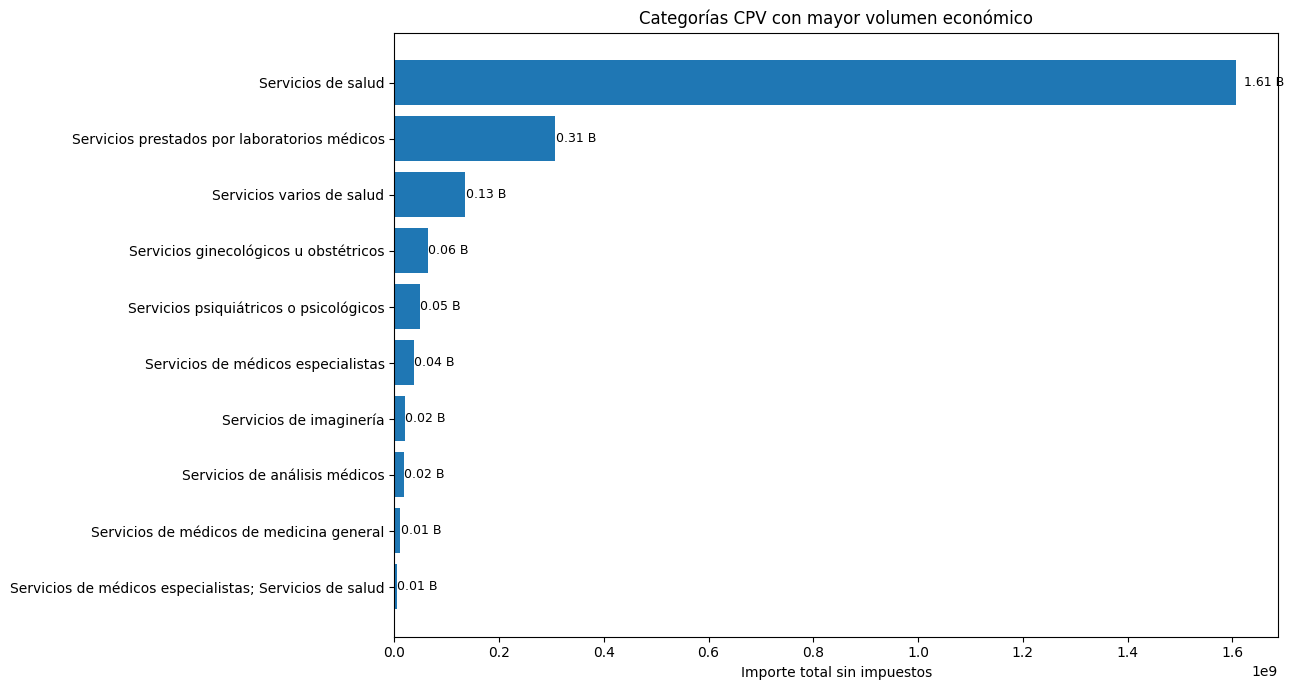

In [166]:
top_importe = (
    cpv_importe
    .head(10)
    .sort_values("importe_total", ascending=True)
)

plt.figure(figsize=(13,7))

bars = plt.barh(
    top_importe["cpv_descripcion"],
    top_importe["importe_total"]
)

# Etiquetas
for bar, valor in zip(bars, top_importe["importe_total"]):

    plt.text(
        valor * 1.01,
        bar.get_y() + bar.get_height()/2,
        f"{valor/1e9:.2f} B",
        va="center",
        fontsize=9
    )

plt.xlabel("Importe total sin impuestos")
plt.ylabel("")

plt.title(
    "Categorías CPV con mayor volumen económico"
)

plt.tight_layout()
plt.show()

In [167]:
top_importe = (
    cpv_importe
    .head(10)
    .sort_values("importe_total", ascending=True)
)
top_importe

,cpv_descripcion,n_licitaciones,importe_total,importe_promedio,importe_mediano
16,Servicios de médicos especialistas; Servicios ...,10,5105644.52,510564.452,616944.95
12,Servicios de médicos de medicina general,33,11726782.64,355357.049697,146280.0
1,Servicios de análisis médicos,41,17653207.78,430566.043415,77000.0
10,Servicios de imaginería,11,19546289.3,1776935.390909,102375.0
15,Servicios de médicos especialistas,55,36960064.29,672001.168909,175000.0
33,Servicios psiquiátricos o psicológicos,47,48378167.36,1029322.709787,63750.0
28,Servicios ginecológicos u obstétricos,46,63976531.19,1390794.156304,572777.32
34,Servicios varios de salud,91,134600702.78,1479128.601978,124700.0
32,Servicios prestados por laboratorios médicos,81,305965963.7,3777357.576543,226994.88
19,Servicios de salud,12049,1606976762.12,133370.135457,1778.1


In [168]:
df_cpv_explotado = (
    df_eda[
        [
            "licitacion_id",
            "cpv_descripcion",
            "importe_sin_impuestos"
        ]
    ]
    .dropna(subset=["cpv_descripcion"])
    .copy()
)

df_cpv_explotado["cpv_descripcion"] = (
    df_cpv_explotado["cpv_descripcion"]
    .str.split(";")
)

df_cpv_explotado = (
    df_cpv_explotado
    .explode("cpv_descripcion")
)

df_cpv_explotado["cpv_descripcion"] = (
    df_cpv_explotado["cpv_descripcion"]
    .str.strip()
)

df_cpv_explotado = (
    df_cpv_explotado
    .reset_index(drop=True)
)

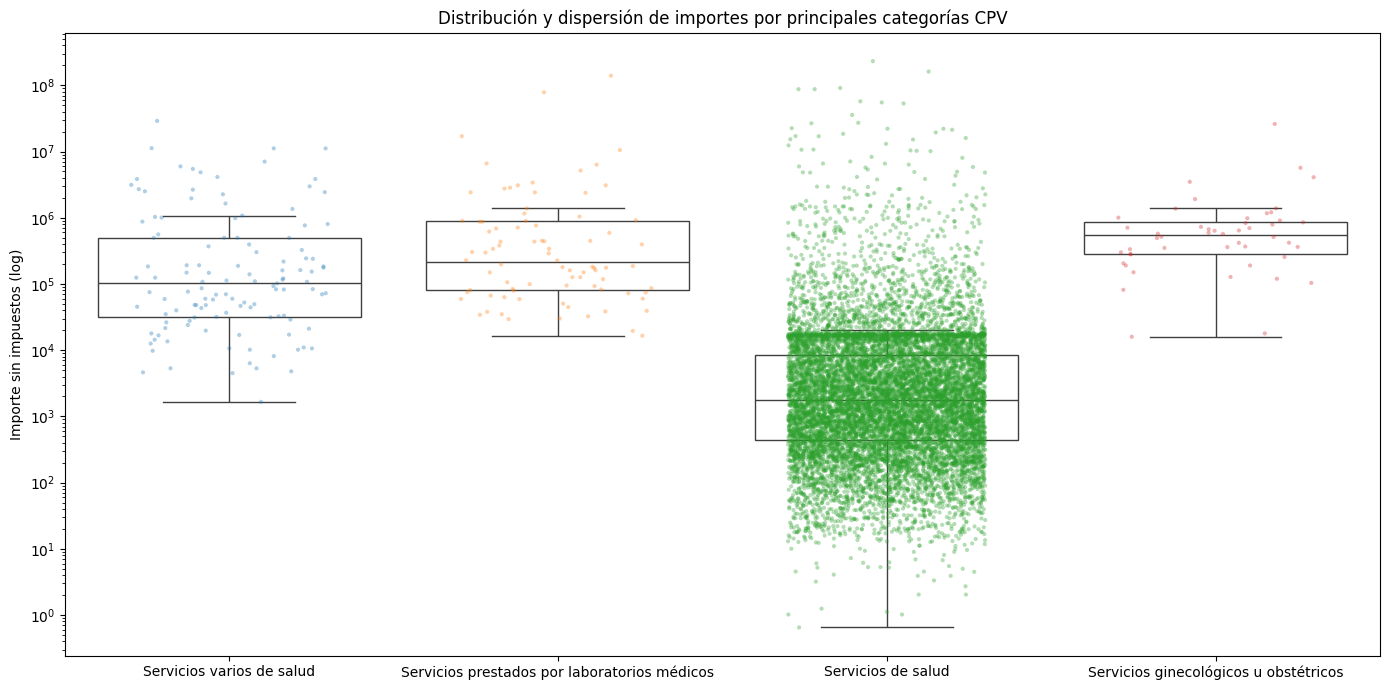

In [169]:
import seaborn as sns
import matplotlib.pyplot as plt

cpv_interes = [
    "Servicios de salud",
    "Servicios prestados por laboratorios médicos",
    "Servicios varios de salud",
    "Servicios ginecológicos u obstétricos",
]

df_dispersion = (
    df_cpv_explotado[
        df_cpv_explotado["cpv_descripcion"].isin(cpv_interes)
    ]
    .copy()
)

plt.figure(figsize=(14,7))

# Boxplot
sns.boxplot(
    data=df_dispersion,
    x="cpv_descripcion",
    y="importe_sin_impuestos",
    showcaps=True,
    boxprops={"facecolor":"white"},
    showfliers=False,
    whiskerprops={"linewidth":1}
)

# Puntos individuales
sns.stripplot(
    data=df_dispersion,
    x="cpv_descripcion",
    y="importe_sin_impuestos",
    hue="cpv_descripcion",
    jitter=0.3,
    alpha=0.35,
    size=3
)

plt.yscale("log")

plt.xlabel("")
plt.ylabel("Importe sin impuestos (log)")

plt.title(
    "Distribución y dispersión de importes por principales categorías CPV"
)

plt.legend([],[], frameon=False)

plt.tight_layout()
plt.show()

## Concentración económica por categoría CPV

El análisis económico por categorías CPV muestra una elevada concentración del volumen licitatorio dentro de un número reducido de categorías directamente relacionadas con la prestación de servicios sanitarios. Este comportamiento es coherente con el proceso de filtrado aplicado en el proyecto, cuyo objetivo fue restringir el análisis a los códigos CPV potencialmente compatibles con la actividad asistencial de Clínica Los Tilos.

La categoría **Servicios de salud** constituye el núcleo principal del universo analizado, acumulando más de 1.600 millones de euros y concentrando más de 12.000 licitaciones. Este resultado refleja que gran parte de las oportunidades identificadas se encuentran agrupadas bajo un CPV generalista que engloba una amplia variedad de servicios asistenciales y sanitarios.

Sin embargo, al analizar categorías más específicas, emergen segmentos con un peso económico relevante pese a contar con un número considerablemente menor de procedimientos. Destacan especialmente los **Servicios prestados por laboratorios médicos**, que acumulan más de 300 millones de euros con únicamente 81 licitaciones registradas. Este comportamiento sugiere la existencia de contratos de elevada magnitud económica asociados a servicios diagnósticos especializados.

Asimismo, categorías como **Servicios varios de salud**, **Servicios ginecológicos u obstétricos**, **Servicios psiquiátricos o psicológicos** y **Servicios de médicos especialistas** presentan importes acumulados significativos dentro del ecosistema analizado, evidenciando la existencia de nichos funcionales específicos dentro del mercado sanitario público.

En conjunto, los resultados muestran que, aunque la contratación sanitaria compatible con Clínica Los Tilos se encuentra dominada por los servicios sanitarios generales, existen áreas especializadas que concentran volúmenes económicos relevantes y que podrían representar oportunidades estratégicas de interés para la institución.

---

## Distribución y dispersión de importes por categoría

El análisis de la distribución de importes revela diferencias estructurales importantes entre las principales categorías CPV identificadas.

La categoría **Servicios de salud** presenta una distribución caracterizada por una elevada frecuencia de contratos de pequeño y mediano importe. Aunque concentra la mayor parte de las licitaciones observadas, su importe mediano se sitúa alrededor de 1.778 euros, lo que indica que gran parte de los procedimientos incluidos en esta categoría corresponden a contrataciones de tamaño relativamente reducido. No obstante, la presencia de valores extremos genera una dispersión considerable y explica su elevado volumen económico acumulado.

Por el contrario, categorías como **Servicios prestados por laboratorios médicos** muestran una estructura económica muy diferente. Con una mediana cercana a 227.000 euros y un importe promedio superior a 3,7 millones de euros, estos contratos presentan un tamaño económico significativamente superior al observado en la categoría general de servicios de salud. Este comportamiento evidencia la existencia de procedimientos especializados con una elevada intensidad presupuestaria.

De manera similar, las categorías **Servicios ginecológicos u obstétricos**, **Servicios psiquiátricos o psicológicos** y **Servicios de imaginería** presentan medianas e importes promedio considerablemente superiores a los observados en la categoría principal, indicando que estos segmentos suelen estar asociados a contratos más complejos y de mayor valor económico.

Desde una perspectiva analítica, los resultados sugieren la existencia de dos grandes patrones dentro de las oportunidades compatibles con Clínica Los Tilos:

| Tipo de segmento | Características |
|------------------|----------------|
| **Servicios sanitarios generales** | Alta frecuencia de licitaciones, importes medianos relativamente bajos y gran heterogeneidad económica. |
| **Servicios especializados** | Menor número de procedimientos, pero contratos de mayor valor económico y mayor intensidad presupuestaria. |

Esta diferenciación resulta especialmente relevante para el sistema de priorización propuesto en el TFM, ya que evidencia que las oportunidades no deben evaluarse únicamente por frecuencia de aparición. Algunas categorías especializadas generan pocas licitaciones, pero concentran contratos de alto valor económico que podrían representar oportunidades estratégicas de especial interés para Clínica Los Tilos dependiendo de sus capacidades asistenciales y técnicas.

# Conclusiones generales — Bloque 2: Estructura funcional y especialización de las oportunidades licitatorias

El análisis de las categorías de la **Clasificación Común de Contratos Públicos (CPV, Common Procurement Vocabulary)** permitió identificar qué tipos de servicios sanitarios concentran las principales oportunidades de contratación pública potencialmente accesibles para Clínica Los Tilos. Los resultados evidenciaron que la categoría **Servicios de salud** constituye el núcleo principal del mercado analizado, concentrando la gran mayoría de las licitaciones identificadas. Este hallazgo indica que la demanda pública asociada a servicios asistenciales generales representa la principal fuente de oportunidades dentro del ecosistema licitatorio compatible con la actividad de la clínica.

Sin embargo, el análisis económico mostró que la frecuencia de contratación no necesariamente coincide con la importancia presupuestaria de una categoría. Aunque los servicios de salud generales concentran la mayor cantidad de procedimientos, algunas categorías especializadas, como los servicios prestados por laboratorios médicos, los servicios ginecológicos u obstétricos, los servicios psiquiátricos o psicológicos y los servicios de imaginería, presentan importes medios y acumulados significativamente superiores. Este comportamiento evidencia la existencia de segmentos especializados con una intensidad económica considerablemente mayor.

Los resultados también permitieron confirmar la existencia de diferencias económicas relevantes entre las distintas áreas asistenciales. Mientras los servicios sanitarios generales se caracterizan por una elevada frecuencia de contratación y una amplia dispersión de importes, las categorías especializadas presentan un menor número de procedimientos, pero contratos de mayor valor económico. Esto demuestra que las distintas especialidades médicas operan bajo dinámicas económicas y competitivas diferentes dentro del mercado de contratación pública.

Adicionalmente, se identificó la presencia de nichos especializados con baja frecuencia de aparición pero alta relevancia económica. Estos segmentos representan oportunidades potencialmente atractivas desde una perspectiva estratégica, ya que pueden combinar una menor recurrencia de procedimientos con contratos de elevada magnitud económica. En consecuencia, la frecuencia de contratación por sí sola no constituye un criterio suficiente para evaluar el atractivo de una categoría licitatoria.

En términos estratégicos, los hallazgos sugieren que las oportunidades compatibles con Clínica Los Tilos no deben analizarse como un conjunto homogéneo. La coexistencia de servicios generalistas de alta frecuencia y especialidades médicas de alto valor económico justifica la incorporación de la **Clasificación Común de Contratos Públicos (CPV)** como una variable clave dentro del futuro sistema de scoring y priorización. Esto permitirá diferenciar oportunidades según su especialidad médica, volumen económico, complejidad operativa y grado de alineación con las capacidades asistenciales de la clínica.

En conjunto, el bloque permitió identificar qué servicios son contratados con mayor frecuencia, cuáles concentran los mayores presupuestos y qué segmentos especializados podrían representar oportunidades estratégicas para Clínica Los Tilos. Estos resultados constituyen una base fundamental para las siguientes fases del proyecto, donde se analizará el comportamiento temporal de las licitaciones y se avanzará hacia la construcción de modelos de priorización y recomendación de oportunidades.

# Bloque 3 — Temporalidad de las oportunidades licitatorias

- ¿Cuándo se concentran las oportunidades compatibles con los servicios de la clínica?
- ¿Existen periodos con mayor publicación de licitaciones?
- ¿Los organismos contratantes siguen patrones temporales diferenciados?
- ¿El volumen económico de las oportunidades presenta variaciones temporales relevantes?
- ¿Existen eventos extraordinarios de publicación que generen grandes concentraciones de oportunidades?

In [170]:
# =========================================================
# BLOQUE 2 — SERIES TEMPORALES
# Cantidad de licitaciones
# Frecuencia mensual y semanal
# =========================================================

# =========================================================
# 1. SERIE MENSUAL
# =========================================================

# Crear variable año-mes
df_eda["year_month"] = (
    df_eda["fecha_publicacion"]
    .dt.to_period("M")
    .astype(str)
)

# Agregación mensual
df_mensual = (
    df_eda
    .groupby("year_month")
    .agg(
        n_licitaciones=(
            "licitacion_id",
            "nunique"
        )
    )
    .reset_index()
)

# Convertir a datetime
df_mensual["year_month"] = pd.to_datetime(
    df_mensual["year_month"]
)

# Ordenar
df_mensual = (
    df_mensual
    .sort_values("year_month")
    .reset_index(drop=True)
)

# Visualizar
df_mensual.head()

,year_month,n_licitaciones
0,2018-01-01,11
1,2018-02-01,9
2,2018-03-01,12
3,2018-05-01,3
4,2018-06-01,3


In [171]:
df_mensual.sort_values(
    "n_licitaciones",
    ascending=False
).head(20)

,year_month,n_licitaciones
59,2023-02-01,8156
60,2023-03-01,3290
55,2022-10-01,331
92,2025-11-01,79
96,2026-03-01,28
97,2026-04-01,27
93,2025-12-01,23
72,2024-03-01,18
79,2024-10-01,17
83,2025-02-01,15


In [172]:
df_feb = df_eda[
    df_eda["fecha_publicacion"].dt.to_period("M") == "2023-02"
]

df_feb["fecha_publicacion"].value_counts().sort_index()

fecha_publicacion
2023-02-01       1
2023-02-06     345
2023-02-07     439
2023-02-08     356
2023-02-09    1810
2023-02-10     430
2023-02-13     966
2023-02-14     122
2023-02-15     659
2023-02-16    1386
2023-02-17     653
2023-02-20     973
2023-02-21      14
2023-02-24       1
2023-02-28       1
Name: count, dtype: int64

In [173]:
df_eda.loc[
    df_eda["fecha_publicacion"] == "2023-02-09",
    "organo_contratacion"
].value_counts().head(20)

organo_contratacion
Consellería de Sanidade  - SERGAS    1810
Name: count, dtype: int64

In [174]:
for fecha in [
    "2023-02-13",
    "2023-02-16",
    "2023-02-20"
]:
    print("\n", fecha)
    print(
        df_eda.loc[
            df_eda["fecha_publicacion"] == fecha,
            "organo_contratacion"
        ].value_counts().head(10)
    )


 2023-02-13
organo_contratacion
Consellería de Sanidade  - SERGAS    966
Name: count, dtype: int64

 2023-02-16
organo_contratacion
Consellería de Sanidade  - SERGAS                                        1385
Directora Gerente del Instituto de Salud Publica y Laboral de Navarra       1
Name: count, dtype: int64

 2023-02-20
organo_contratacion
Consellería de Sanidade  - SERGAS    973
Name: count, dtype: int64


In [175]:
df_eda.loc[
    df_eda["fecha_publicacion"] == "2023-02-09",
    "licitacion_id"
].nunique()

1810

In [176]:
len(
    df_eda.loc[
        df_eda["fecha_publicacion"] == "2023-02-09"
    ]
)

1810

In [177]:
df_eda.loc[
    df_eda["fecha_publicacion"] == "2023-02-09",
    "cpv_descripcion"
].value_counts().head(20)

cpv_descripcion
Servicios de salud    1810
Name: count, dtype: int64

In [178]:
df_eda.loc[
    df_eda["fecha_publicacion"] == "2023-02-09",
    [
        "licitacion_id",
        "organo_contratacion",
        "titulo"
    ]
].sample(20)

,licitacion_id,organo_contratacion,titulo
3212,e1c86cbd7079732d,Consellería de Sanidade - SERGAS,059982 - epi bota pac nº 42
1953,1e806dea1d105ff6,Consellería de Sanidade - SERGAS,Mascara cirurxica tipo ii n/esteril c/cintas
2840,c12900786d19b797,Consellería de Sanidade - SERGAS,Traslado muestras desde hvx la huac y laborato...
2889,e6c7fa6e8ca9418d,Consellería de Sanidade - SERGAS,Covid-19 incremento personal lavg-sept
2607,acb2b20aef949bcf,Consellería de Sanidade - SERGAS,Sensor de oxigeno p/respirador
2358,4a90c3797f62349b,Consellería de Sanidade - SERGAS,Traslado muestras desde hvx la huac y laborato...
3495,5c8d690d8d87c493,Consellería de Sanidade - SERGAS,Suministro de carros de medicación (10 uds) pa...
2184,d54242588e76eb26,Consellería de Sanidade - SERGAS,Epi mascara proteccion rogada s/valvula ffp3
3523,43cc227443096df8,Consellería de Sanidade - SERGAS,dolquine (covid-19) 200 mg 30 comprimidos (me)
2242,63689a5f3d60b529,Consellería de Sanidade - SERGAS,Dispositivo extraordinario c.salud cee/dumbria...


In [179]:
df_eda.loc[
    df_eda["fecha_publicacion"] == "2023-02-09",
    "titulo"
].head(50)

1827        Adaptacion la situacion de emergencia en huac
1828    Covid-19 incremento   limpieza/ desinfección r...
1829    Covid-19 incremento   limpieza/ desinfección r...
1830    Covid-19 incremento   limpieza/ desinfección r...
1831    Covid-19 incrementos  limpieza/ desinfección c...
1832                     Bajante para cubierta covid auto
1833    Cierres con puertas en los antigus quirofanos ...
1834    Hvx.fabricación, transporte e instalación de m...
1835    Instalacion de modulo covid-auto en en c.y. Ve...
1836    Instalacion informática e iluminación de modul...
1837    Covid-19 incrementos  limpieza/ desinfección c...
1838                     Auxiliar de servicios (12 horas)
1839    Aps desparramo alcatel para chuac desdobl. cir...
1840                Personal apoyo vpn noviembre covid 19
1841    Covid-19 incrementos  limpieza/ desinfección h...
1842    Covid-19 incrementos limpieza/ desinfección ce...
1843                   Limpieza 13 vehiculos domicilios º
1844          

In [180]:
df_eda["organo_contratacion"].value_counts().head(20)

organo_contratacion
Consellería de Sanidade  - SERGAS                                          11752
Servicio Andaluz de Salud                                                    218
Servicio Madrileño de Salud                                                   39
Director Gerente del Servicio Navarro de Salud-Osasunbidea                    17
Fundació Hospital Universitari Vall d'Hebron - Institut de Recerca            16
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                  16
Fundación Rioja Salud                                                         15
Consejería de Sanidad                                                         13
Empresa Pública de Metro de Madrid, S.A.                                      12
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau        11
Ajuntament de l'Hospitalet de Llobregat                                       11
Servicio Riojano de Salud                                                     11
Fundació

In [181]:
(
    df_eda["organo_contratacion"]
    .value_counts(normalize=True)
    .mul(100)
    .head(20)
)

organo_contratacion
Consellería de Sanidade  - SERGAS                                          93.351338
Servicio Andaluz de Salud                                                   1.731671
Servicio Madrileño de Salud                                                 0.309794
Director Gerente del Servicio Navarro de Salud-Osasunbidea                  0.135039
Fundació Hospital Universitari Vall d'Hebron - Institut de Recerca          0.127095
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                0.127095
Fundación Rioja Salud                                                       0.119152
Consejería de Sanidad                                                       0.103265
Empresa Pública de Metro de Madrid, S.A.                                    0.095321
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau      0.087378
Ajuntament de l'Hospitalet de Llobregat                                     0.087378
Servicio Riojano de Salud                    

In [182]:
df_eda["organo_contratacion"].value_counts().head(20)

organo_contratacion
Consellería de Sanidade  - SERGAS                                          11752
Servicio Andaluz de Salud                                                    218
Servicio Madrileño de Salud                                                   39
Director Gerente del Servicio Navarro de Salud-Osasunbidea                    17
Fundació Hospital Universitari Vall d'Hebron - Institut de Recerca            16
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                  16
Fundación Rioja Salud                                                         15
Consejería de Sanidad                                                         13
Empresa Pública de Metro de Madrid, S.A.                                      12
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau        11
Ajuntament de l'Hospitalet de Llobregat                                       11
Servicio Riojano de Salud                                                     11
Fundació

In [183]:
(
    df_eda["organo_contratacion"]
    .value_counts(normalize=True)
    .mul(100)
    .head(20)
)

organo_contratacion
Consellería de Sanidade  - SERGAS                                          93.351338
Servicio Andaluz de Salud                                                   1.731671
Servicio Madrileño de Salud                                                 0.309794
Director Gerente del Servicio Navarro de Salud-Osasunbidea                  0.135039
Fundació Hospital Universitari Vall d'Hebron - Institut de Recerca          0.127095
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                0.127095
Fundación Rioja Salud                                                       0.119152
Consejería de Sanidad                                                       0.103265
Empresa Pública de Metro de Madrid, S.A.                                    0.095321
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau      0.087378
Ajuntament de l'Hospitalet de Llobregat                                     0.087378
Servicio Riojano de Salud                    

In [184]:
df_eda[
    "organo_contratacion"
].value_counts().head(30)

organo_contratacion
Consellería de Sanidade  - SERGAS                                          11752
Servicio Andaluz de Salud                                                    218
Servicio Madrileño de Salud                                                   39
Director Gerente del Servicio Navarro de Salud-Osasunbidea                    17
Fundació Hospital Universitari Vall d'Hebron - Institut de Recerca            16
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                  16
Fundación Rioja Salud                                                         15
Consejería de Sanidad                                                         13
Empresa Pública de Metro de Madrid, S.A.                                      12
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau        11
Ajuntament de l'Hospitalet de Llobregat                                       11
Servicio Riojano de Salud                                                     11
Fundació

In [185]:
df_eda.groupby("organo_contratacion").agg(
    n_licitaciones=("licitacion_id", "nunique"),
    importe_total=("importe_sin_impuestos", "sum")
).sort_values(
    "importe_total",
    ascending=False
).head(20)

,n_licitaciones,importe_total
organo_contratacion,,
Servicio Andaluz de Salud,218,1165892957.39
Consellería de Sanidade - SERGAS,11752,275838746.62
Servicio Madrileño de Salud,39,178630271.79
Agencia de Contratación Sanitaria de la Comunidad de Madrid,5,155309134.3
Consejería de Salud y Familias. Secretaría General Técnica,4,103466952.0
Consejería de Salud y Consumo. Secretaría General Técnica,9,67624320.0
Fundació de Gestió Sanitària de l'Hospital de la Santa Creu i Sant Pau,11,48320226.71
Director Gerente del Servicio Navarro de Salud-Osasunbidea,17,41657225.83
"Consejería de Sanidad, Presidencia y Emergencias Secretaría General Técnica de Sanidad y Consumo",2,33260627.52


In [186]:
df_eda.loc[
    df_eda["organo_contratacion"] == "Consellería de Sanidade - SERGAS",
    "adjudicatario"
].nunique()

0

In [187]:
df_eda["adjudicatario"].isna().mean() * 100

np.float64(0.0)

In [188]:
df_eda["adjudicatario"].notna().sum()

np.int64(12589)

In [189]:
(
    df_eda.loc[
        df_eda["organo_contratacion"] == "Consellería de Sanidade - SERGAS",
        "adjudicatario"
    ]
    .value_counts()
    .head(20)
)

Series([], Name: count, dtype: int64)

In [190]:
sergas_adj = (
    df_eda.loc[
        df_eda["organo_contratacion"] == "Consellería de Sanidade - SERGAS"
    ]
    .groupby("adjudicatario")
    .agg(
        n_licitaciones=("licitacion_id", "nunique"),
        importe_total=("importe_sin_impuestos", "sum")
    )
    .sort_values(
        "importe_total",
        ascending=False
    )
)

sergas_adj.head(20)

,n_licitaciones,importe_total
adjudicatario,,


In [191]:
df_eda["titulo"].str.contains(
    "covid",
    case=False,
    na=False
).mean() * 100

np.float64(34.244181428230995)

In [192]:
df_eda.loc[
    df_eda["organo_contratacion"] == "Consellería de Sanidade - SERGAS",
    "adjudicatario"
].value_counts()

Series([], Name: count, dtype: int64)

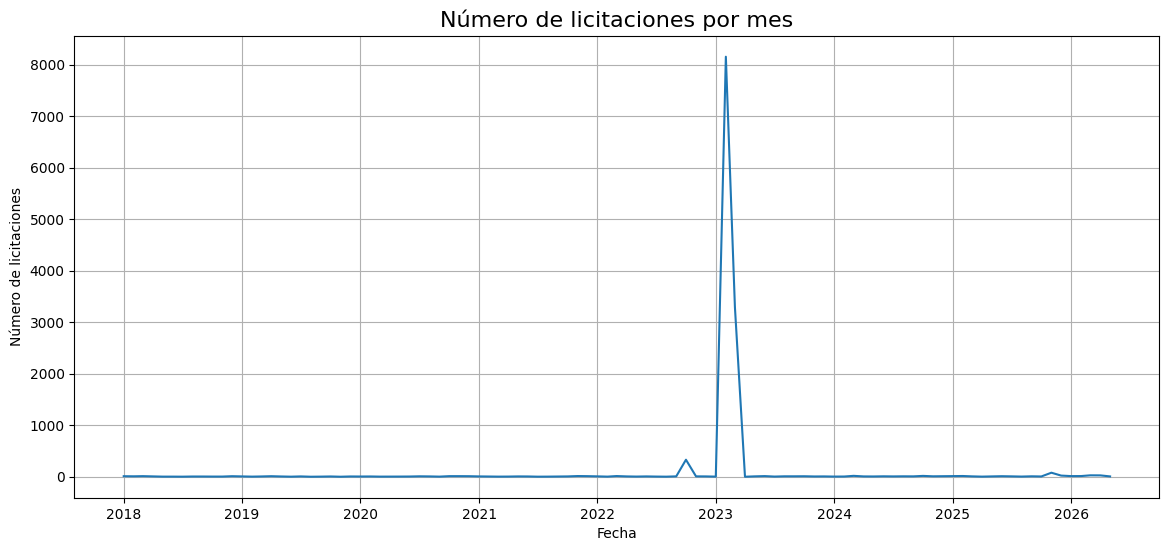

In [193]:
# =========================================================
# GRÁFICA — LICITACIONES POR MES
# =========================================================

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.plot(
    df_mensual["year_month"],
    df_mensual["n_licitaciones"]
)

plt.title(
    "Número de licitaciones por mes",
    fontsize=16
)

plt.xlabel("Fecha")
plt.ylabel("Número de licitaciones")

plt.grid(True)

plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17420\1996475189.py:17: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


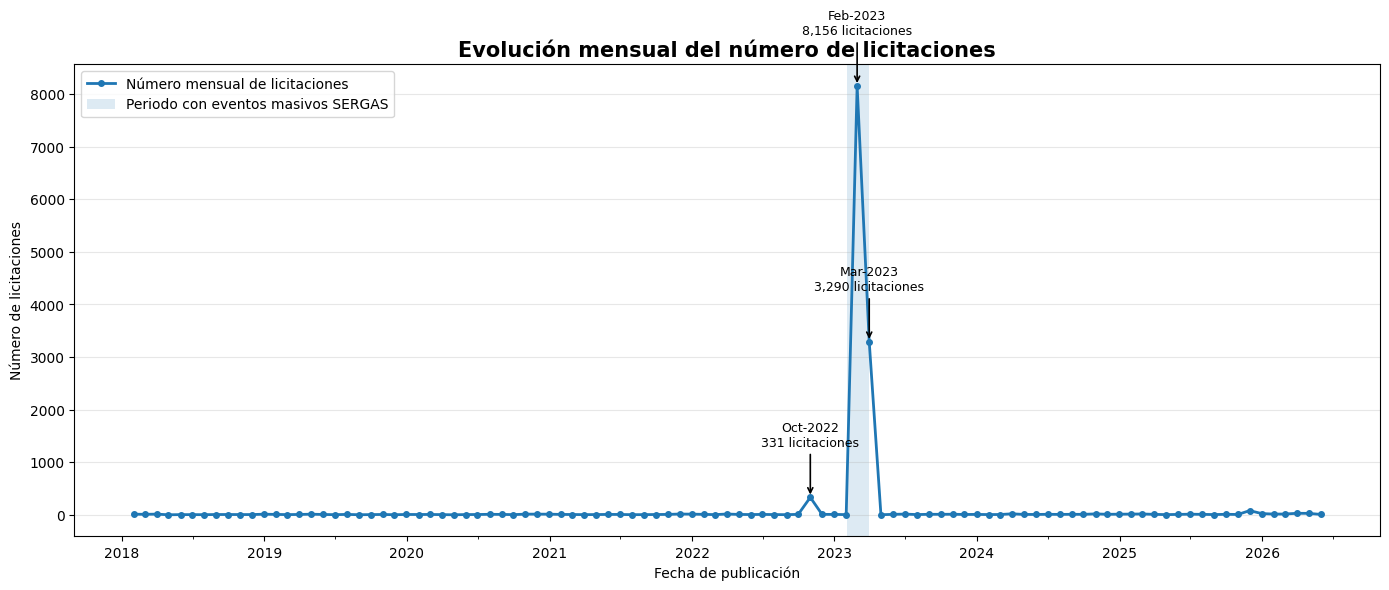

In [252]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ===============================
# 1. Preparar serie temporal mensual
# ===============================

df_eda["fecha_publicacion"] = pd.to_datetime(
    df_eda["fecha_publicacion"],
    errors="coerce"
)

serie_mensual = (
    df_eda
    .dropna(subset=["fecha_publicacion"])
    .set_index("fecha_publicacion")
    .resample("M")
    .size()
)

# ===============================
# 2. Crear figura
# ===============================

fig, ax = plt.subplots(figsize=(14, 6))

# Línea temporal
ax.plot(
    serie_mensual.index,
    serie_mensual.values,
    marker="o",
    linewidth=2,
    markersize=4,
    label="Número mensual de licitaciones"
)

# ===============================
# 3. Resaltar periodo SERGAS
# ===============================

inicio_sergas = pd.to_datetime("2023-02-01")
fin_sergas = pd.to_datetime("2023-03-31")

ax.axvspan(
    inicio_sergas,
    fin_sergas,
    alpha=0.15,
    label="Periodo con eventos masivos SERGAS"
)

# ===============================
# 4. Anotar principales picos
# ===============================

picos = serie_mensual.sort_values(ascending=False).head(3)

for fecha, valor in picos.items():
    ax.annotate(
        f"{fecha.strftime('%b-%Y')}\n{valor:,.0f} licitaciones",
        xy=(fecha, valor),
        xytext=(fecha, valor + serie_mensual.max() * 0.12),
        arrowprops=dict(arrowstyle="->", linewidth=1.2),
        fontsize=9,
        ha="center"
    )

# ===============================
# 5. Formato del gráfico
# ===============================

ax.set_title(
    "Evolución mensual del número de licitaciones",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel("Fecha de publicación")
ax.set_ylabel("Número de licitaciones")

ax.grid(axis="y", alpha=0.3)

# Formato del eje X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

C:\Users\Usuario\AppData\Local\Temp\ipykernel_17420\645743800.py:18: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  .resample("M")


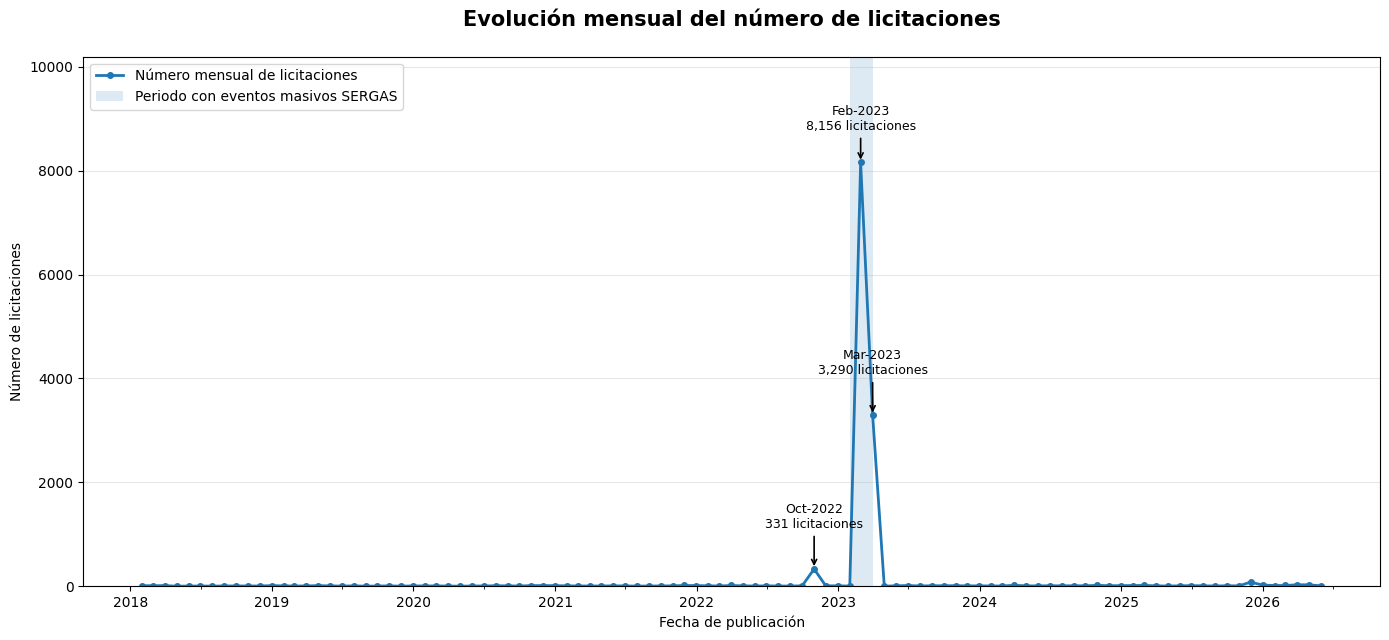

In [254]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# ===============================
# 1. Preparar serie temporal mensual
# ===============================

df_eda["fecha_publicacion"] = pd.to_datetime(
    df_eda["fecha_publicacion"],
    errors="coerce"
)

serie_mensual = (
    df_eda
    .dropna(subset=["fecha_publicacion"])
    .set_index("fecha_publicacion")
    .resample("M")
    .size()
)

# ===============================
# 2. Crear figura
# ===============================

fig, ax = plt.subplots(figsize=(14, 6.5))

# Línea temporal
ax.plot(
    serie_mensual.index,
    serie_mensual.values,
    marker="o",
    linewidth=2,
    markersize=4,
    label="Número mensual de licitaciones"
)

# ===============================
# 3. Resaltar periodo SERGAS
# ===============================

inicio_sergas = pd.to_datetime("2023-02-01")
fin_sergas = pd.to_datetime("2023-03-31")

ax.axvspan(
    inicio_sergas,
    fin_sergas,
    alpha=0.15,
    label="Periodo con eventos masivos SERGAS"
)

# ===============================
# 4. Anotar principales picos
# ===============================

picos = serie_mensual.sort_values(ascending=False).head(3)

for fecha, valor in picos.items():

    # Ajustar desplazamiento según el tamaño del pico
    if valor == serie_mensual.max():
        desplazamiento = serie_mensual.max() * 0.07
    else:
        desplazamiento = serie_mensual.max() * 0.09

    ax.annotate(
        f"{fecha.strftime('%b-%Y')}\n{valor:,.0f} licitaciones",
        xy=(fecha, valor),
        xytext=(fecha, valor + desplazamiento),
        arrowprops=dict(arrowstyle="->", linewidth=1.2),
        fontsize=9,
        ha="center",
        va="bottom"
    )

# ===============================
# 5. Formato del gráfico
# ===============================

ax.set_title(
    "Evolución mensual del número de licitaciones",
    fontsize=15,
    fontweight="bold",
    pad=22
)

ax.set_xlabel("Fecha de publicación")
ax.set_ylabel("Número de licitaciones")

# Subir límite superior del eje Y para que las etiquetas no choquen con el título
ax.set_ylim(0, serie_mensual.max() * 1.25)

ax.grid(axis="y", alpha=0.3)

# Formato del eje X
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=6))

ax.legend(loc="upper left")

plt.tight_layout()
plt.show()

In [194]:
# =========================================================
# 2. SERIE SEMANAL
# =========================================================

# Crear variable año-semana
df_eda["year_week"] = (
    df_eda["fecha_publicacion"]
    .dt.to_period("W")
    .astype(str)
)

# Agregación semanal
df_semanal = (
    df_eda
    .groupby("year_week")
    .agg(
        n_licitaciones=(
            "licitacion_id",
            "nunique"
        )
    )
    .reset_index()
)

# Convertir inicio de semana a datetime
df_semanal["fecha_semana"] = pd.to_datetime(
    df_semanal["year_week"]
    .str.split("/")
    .str[0]
)

# Ordenar
df_semanal = (
    df_semanal
    .sort_values("fecha_semana")
    .reset_index(drop=True)
)

# Visualizar
df_semanal.head()

,year_week,n_licitaciones,fecha_semana
0,2018-01-01/2018-01-07,2,2018-01-01
1,2018-01-08/2018-01-14,2,2018-01-08
2,2018-01-15/2018-01-21,5,2018-01-15
3,2018-01-22/2018-01-28,1,2018-01-22
4,2018-01-29/2018-02-04,1,2018-01-29


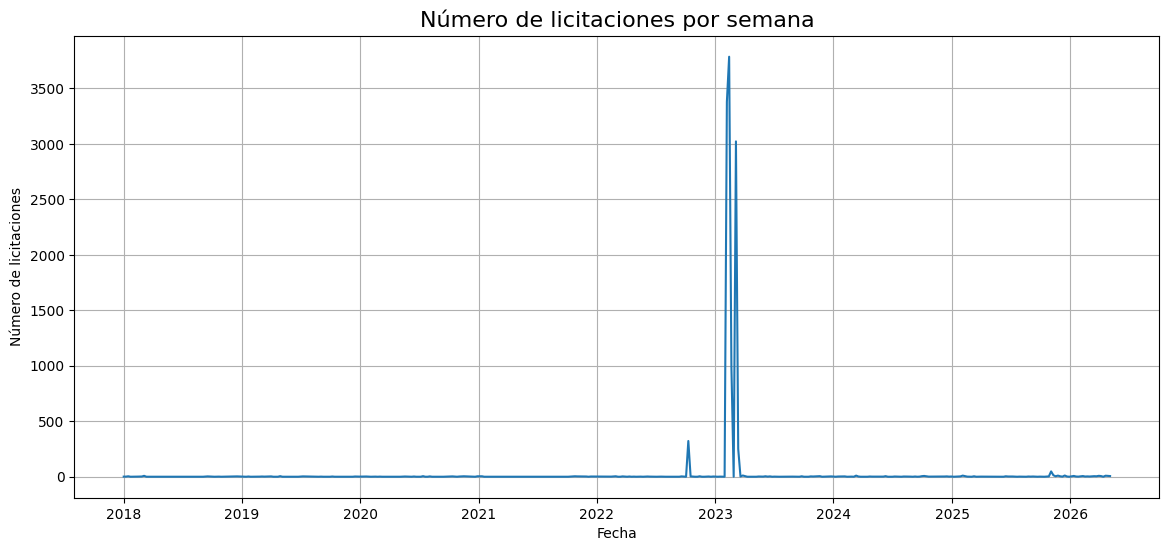

In [195]:
# =========================================================
# GRÁFICA — LICITACIONES POR SEMANA
# =========================================================

plt.figure(figsize=(14,6))

plt.plot(
    df_semanal["fecha_semana"],
    df_semanal["n_licitaciones"]
)

plt.title(
    "Número de licitaciones por semana",
    fontsize=16
)

plt.xlabel("Fecha")
plt.ylabel("Número de licitaciones")

plt.grid(True)

plt.show()

### Validación de la distribución temporal e institucional de las licitaciones

Durante el análisis temporal de las licitaciones se identificó una concentración extraordinaria de registros en los meses de febrero y marzo de 2023. Inicialmente, este comportamiento fue interpretado como una posible anomalía temporal debido a que la serie mostraba un pico superior a las 8.000 licitaciones en febrero de 2023 y más de 3.000 licitaciones en marzo del mismo año, concentrando conjuntamente más del 90% de los registros presentes en la base de datos.

Con el fin de determinar si este comportamiento correspondía a un error en la construcción de la base o a un fenómeno real de contratación pública, se realizó una auditoría específica sobre los registros asociados a dicho periodo. En primer lugar, se verificó que los conteos temporales estaban calculados sobre identificadores únicos de licitación (`licitacion_id`), descartando así la existencia de duplicados simples. Posteriormente, se comprobó que las fechas de publicación no correspondían a valores imputados o fechas por defecto, ya que los registros se encontraban distribuidos entre distintos días de febrero y marzo de 2023.

La revisión detallada permitió identificar que la práctica totalidad de estas licitaciones procedía de un único órgano de contratación: la **Consellería de Sanidade – SERGAS (Servicio Gallego de Salud)**. En concreto, este organismo concentra 11.752 licitaciones de las 12.589 incluidas en la base analizada, representando aproximadamente el 93,35% del total de registros. Asimismo, se observó que varios de los días con mayor actividad correspondían a publicaciones masivas realizadas por este organismo, alcanzando más de 1.800 licitaciones en una sola fecha.

Adicionalmente, el análisis de los títulos de los expedientes reveló una elevada presencia de actuaciones relacionadas con la pandemia de COVID-19, incluyendo servicios de limpieza y desinfección, apoyo asistencial, logística sanitaria, transporte, farmacia y adecuación de infraestructuras. De hecho, aproximadamente el 34% de los títulos contienen referencias explícitas a COVID-19, lo que sugiere que una parte significativa de los procedimientos publicados durante este periodo estuvo asociada a necesidades extraordinarias derivadas de la emergencia sanitaria.

La auditoría permitió descartar errores de duplicación o problemas en la variable de fecha de publicación. Sin embargo, puso de manifiesto una elevada concentración institucional dentro de la muestra, donde un único organismo público domina gran parte de los registros disponibles. Este hallazgo tiene implicaciones metodológicas relevantes para la interpretación de los análisis temporales, ya que las tendencias observadas reflejan en gran medida el comportamiento de publicación de SERGAS durante el periodo analizado y no necesariamente la evolución general del conjunto de oportunidades de contratación sanitaria en España.

En consecuencia, los resultados temporales posteriores deberán interpretarse considerando esta concentración institucional, diferenciando entre patrones propios del mercado sanitario en general y comportamientos derivados de publicaciones masivas realizadas por organismos específicos.


In [196]:
# ==========================================
# Eliminar eventos masivos SERGAS
# Febrero y marzo 2023
# ==========================================

mask_sergas = df_eda["organo_contratacion"].str.contains(
    "SERGAS",
    case=False,
    na=False
)

mask_feb_mar_2023 = (
    (df_eda["fecha_publicacion"].dt.year == 2023)
    &
    (df_eda["fecha_publicacion"].dt.month.isin([2, 3]))
)

df_sin_picos = df_eda[
    ~(mask_sergas & mask_feb_mar_2023)
].copy()

print("Base original:", len(df_eda))
print("Base sin picos:", len(df_sin_picos))
print("Registros eliminados:", len(df_eda) - len(df_sin_picos))

Base original: 12589
Base sin picos: 1169
Registros eliminados: 11420


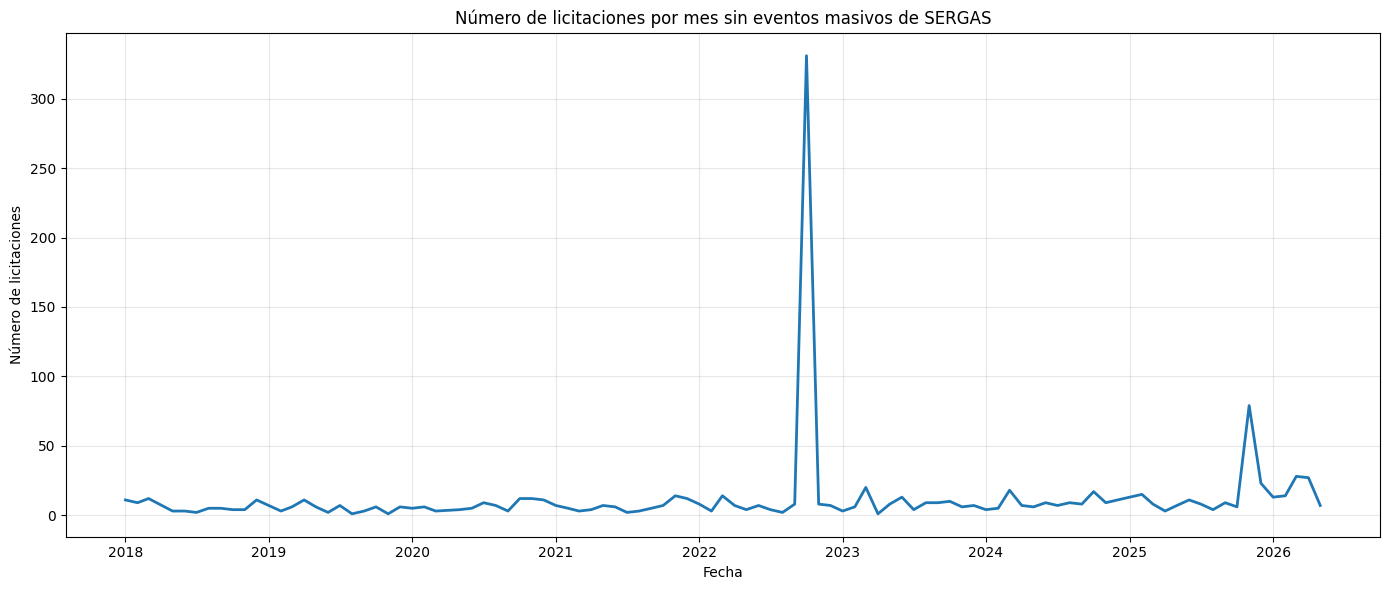

In [197]:
df_mensual_sin_picos = (
    df_sin_picos
    .assign(
        year_month=df_sin_picos["fecha_publicacion"].dt.to_period("M").astype(str)
    )
    .groupby("year_month")
    .agg(n_licitaciones=("licitacion_id", "nunique"))
    .reset_index()
)

df_mensual_sin_picos["year_month"] = pd.to_datetime(df_mensual_sin_picos["year_month"])
df_mensual_sin_picos = df_mensual_sin_picos.sort_values("year_month")

import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))
plt.plot(
    df_mensual_sin_picos["year_month"],
    df_mensual_sin_picos["n_licitaciones"],
    linewidth=2
)

plt.title("Número de licitaciones por mes sin eventos masivos de SERGAS")
plt.xlabel("Fecha")
plt.ylabel("Número de licitaciones")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [198]:
df_mensual_sin_picos.sort_values(
    "n_licitaciones",
    ascending=False
).head(10)

,year_month,n_licitaciones
55,2022-10-01,331
92,2025-11-01,79
96,2026-03-01,28
97,2026-04-01,27
93,2025-12-01,23
60,2023-03-01,20
72,2024-03-01,18
79,2024-10-01,17
83,2025-02-01,15
44,2021-11-01,14


In [199]:
df_eda.loc[
    df_eda["fecha_publicacion"].dt.to_period("M") == "2022-10",
    "organo_contratacion"
].value_counts().head(20)

organo_contratacion
Consellería de Sanidade  - SERGAS                                                                  322
Servicio Andaluz de Salud                                                                            2
Fundació Institut Hospital del Mar d'Investigacions Mèdiques                                         2
Servicio Riojano de Salud                                                                            1
Ajuntament d'Olivella                                                                                1
Directora Gerente del Instituto de Salud Pública y Laboral de Navarra                                1
Institut Català de la Salut (ICS)                                                                    1
Consorcio para el Servicio de Extinción de Incendios, Salvamento y Protección Civil de La Rioja      1
Name: count, dtype: int64

### Conclusiones del análisis temporal

El análisis temporal de las licitaciones compatibles con los servicios prestados por Clínica Los Tilos permitió identificar que la actividad observada no sigue una evolución homogénea a lo largo del tiempo. Inicialmente, la serie temporal mostraba una concentración extraordinaria de licitaciones durante determinados meses, particularmente en octubre de 2022 y febrero-marzo de 2023. La auditoría realizada sobre estos picos permitió comprobar que no correspondían a errores de captura, duplicidades o problemas de calidad de los datos, sino a eventos reales de publicación masiva realizados por la Consellería de Sanidade – SERGAS.

Los resultados evidencian que este organismo concentra aproximadamente el 93% de las licitaciones incluidas en la muestra, generando miles de oportunidades asociadas principalmente a servicios sanitarios y actuaciones derivadas de necesidades asistenciales extraordinarias. Como consecuencia, la serie temporal queda fuertemente condicionada por el comportamiento de este órgano de contratación, dificultando la identificación de tendencias generales, patrones estacionales o ciclos recurrentes representativos del conjunto del mercado.

Tras analizar la serie excluyendo los principales eventos masivos de publicación, no se observaron evidencias claras de estacionalidad ni de tendencias crecientes o decrecientes sostenidas en el tiempo. La actividad restante presenta un comportamiento relativamente estable, caracterizado por volúmenes moderados de licitaciones y variaciones puntuales asociadas a procesos específicos de contratación.

Desde la perspectiva del presente proyecto, este resultado tiene una implicación relevante. El objetivo principal no consiste en predecir el comportamiento futuro del mercado licitatorio, sino en identificar oportunidades potencialmente compatibles con los servicios ofrecidos por Clínica Los Tilos. En este contexto, los hallazgos sugieren que la variable temporal posee una capacidad explicativa limitada para la identificación de oportunidades, mientras que variables asociadas al órgano de contratación adquieren una importancia estratégica considerablemente mayor.

En consecuencia, más que seguir patrones temporales complejos, los resultados indican que una estrategia de monitorización basada en los principales organismos contratantes, especialmente aquellos que generan un volumen elevado de oportunidades compatibles con la actividad de la clínica, podría aportar un mayor valor operativo al sistema de priorización propuesto. Particularmente, la elevada concentración observada en SERGAS sugiere que determinados organismos públicos actúan como generadores recurrentes de oportunidades y, por tanto, constituyen un foco de interés prioritario para futuras estrategias de seguimiento y análisis.

En síntesis, el análisis temporal muestra que, para el objetivo del proyecto, no resulta tan relevante identificar únicamente cuándo se publican las licitaciones, sino comprender quién las publica y si el servicio licitado coincide con las capacidades operativas y asistenciales de Clínica Los Tilos. Por tanto, la temporalidad funciona como una variable descriptiva complementaria, mientras que el órgano de contratación y la compatibilidad del servicio adquieren mayor importancia dentro del sistema de priorización propuesto.


# Ciudades

In [200]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import skew, kurtosis

In [201]:
tabla_nuts = pd.read_excel("../data/tabla_codigos_nuts_completa.xlsx")

In [202]:
tabla_nuts.head()

,codigo_nuts,nombre_region
0,ES,España
1,ES11,Galicia
2,ES111,A Coruña
3,ES112,Lugo
4,ES113,Ourense


In [203]:
df_eda = df_eda.merge(
    tabla_nuts,
    how="left",
    left_on="lugar_ejecucion_codigo",
    right_on="codigo_nuts"
)

In [204]:
df_eda[[
    "lugar_ejecucion_codigo",
    "codigo_nuts"
]].head(20)

,lugar_ejecucion_codigo,codigo_nuts
0,ES300,ES300
1,ES418,ES418
2,ES300,ES300
3,ES213,ES213
4,ES705,ES705
5,ES11,ES11
6,ES212,ES212
7,ES212,ES212
8,ES21,ES21
9,ES300,ES300


In [205]:
df_eda["codigo_nuts"].isna().sum()

np.int64(6)

In [206]:
df_eda.loc[
    df_eda["lugar_ejecucion_codigo"].notna() &
    df_eda["codigo_nuts"].isna(),
    "lugar_ejecucion_codigo"
].value_counts()

lugar_ejecucion_codigo
    1
Name: count, dtype: int64

In [207]:
df_eda.head()

,licitacion_id,titulo,detail_url,updated,expediente,tipo_contrato_codigo,lugar_ejecucion_codigo,cpv_codes,organo_contratacion,estado_codigo,...,tipo_contrato,url,cpv_descripcion,cpv_nivel,importe_log,tamano_licitacion,year_month,year_week,codigo_nuts,nombre_region
0,9239cad837632514,Servicio de prevención de adicciones en ocio y...,http://www.madrid.org/cs/Satellite?op2=PCON&id...,2018-01-05,12/2017 (A/SER-007399/2017),Servicios,ES300,85140000,Consejería de Sanidad,RES,...,Servicios,http://www.madrid.org/cs/Satellite?op2=PCON&id...,Servicios varios de salud,Clase,11.322301,Grande,2018-01,2018-01-01/2018-01-07,ES300,Madrid
1,448f6964aebcd861,realización de pruebas analíticas por laborato...,https://contratacion.jcyl.es/web/jcyl/Contrata...,2018-02-14,0000-00C-1-2018-06870,Servicios,ES418,85145000,Gerencia Regional de Salud (SACyL),EV,...,Servicios,https://contratacion.jcyl.es/web/jcyl/Contrata...,Servicios prestados por laboratorios médicos,Categoría,13.963621,Muy grande,2018-01,2018-01-01/2018-01-07,ES418,Valladolid
2,f37ce812644369e9,Unidad móvil de prevención y diagnóstico preco...,http://www.madrid.org/cs/Satellite?op2=PCON&id...,2018-02-15,: 56/2017 (A/SER-012602/2017),Servicios,ES300,85140000,Consejería de Sanidad,EV,...,Servicios,http://www.madrid.org/cs/Satellite?op2=PCON&id...,Servicios varios de salud,Clase,12.122696,Muy grande,2018-01,2018-01-08/2018-01-14,ES300,Madrid
3,58a2b0f21be4191c,Servicios de asistencia psiquiátrica a persona...,https://apps.euskadi.eus/w32-1084/es/contenido...,2018-01-11,2/2018 PS,Concesion de obras,ES213,85121270,Dirección Territorial de Bizkaia,RES,...,Concesion de obras,https://apps.euskadi.eus/w32-1084/es/contenido...,Servicios psiquiátricos o psicológicos,Detalle,12.661077,Muy grande,2018-01,2018-01-08/2018-01-14,ES213,Vizcaya
4,6ca4112ec156b9d7,Servicio de realización de diagnósticos citoló...,http://www.gobiernodecanarias.org/perfildelcon...,2018-01-15,54/S/17/SS/GE/A/0049,Servicios,ES705,85145000,Dirección Gerencia del Comp.Hosp.Univ. Insular...,PUB,...,Servicios,http://www.gobiernodecanarias.org/perfildelcon...,Servicios prestados por laboratorios médicos,Categoría,11.22792,Grande,2018-01,2018-01-15/2018-01-21,ES705,Gran Canaria


In [208]:
df_eda["nombre_region"].notna().sum()

np.int64(12583)

In [209]:
(
    df_eda["nombre_region"]
    .notna()
    .mean()
) * 100

np.float64(99.95233934387163)

In [210]:
(
    df_eda
    .groupby("nombre_region")["importe_sin_impuestos"]
    .sum()
    .sort_values(ascending=False)
    .head(20)
)

nombre_region
Andalucía     560229240.89
Madrid        367262446.53
Jaén           231382278.6
A Coruña      227673551.09
Sevilla       149717835.08
Málaga        120662296.89
Granada       104505486.03
Cádiz          84749269.27
Almería        69170227.98
Barcelona      66601441.82
Navarra        44507980.51
Vizcaya        34951196.77
Córdoba        34945220.99
Huelva         26420916.47
La Rioja       24909593.28
Ourense        22692123.73
Galicia        19730232.14
Pontevedra     15096265.13
Guipúzcoa      14886126.95
Lugo           13083177.86
Name: importe_sin_impuestos, dtype: Float64

In [211]:
(
    df_eda
    .groupby("nombre_region")["importe_sin_impuestos"]
    .mean()
    .sort_values(ascending=False)
    .head(20)
)

nombre_region
Jaén             15425485.24
Cádiz         10593658.65875
Andalucía     8488321.831667
Granada       4543716.783913
Sevilla       4536904.093333
Almería           4068836.94
Huelva         3302614.55875
Málaga        2806099.927674
Murcia        2388346.923333
Madrid        2309826.707736
Navarra       1483599.350333
Galicia       1160601.890588
Valladolid         1159639.8
Vizcaya         873779.91925
Barcelona       802427.00988
Cataluña       721333.867647
Córdoba        546019.077969
Guipúzcoa      531647.391071
La Rioja       444814.165714
Palencia           289483.96
Name: importe_sin_impuestos, dtype: Float64

In [212]:
(
    df_eda[
        ["codigo_nuts", "nombre_region"]
    ]
    .drop_duplicates()
    .sort_values("codigo_nuts")
    .head(100)
)

,codigo_nuts,nombre_region
307,ES,España
5,ES11,Galicia
79,ES111,A Coruña
83,ES112,Lugo
2908,ES113,Ourense
80,ES114,Pontevedra
72,ES120,Asturias
8,ES21,País Vasco
52,ES211,Álava
6,ES212,Guipúzcoa


In [213]:
df_ccaa = (
    df_eda[
        df_eda["codigo_nuts"]
        .str.len() == 4
    ]
    .copy()
)

In [214]:
df_ccaa["nombre_region"].value_counts()

nombre_region
Andalucía     66
País Vasco    33
Galicia       17
Cataluña      17
Madrid         4
Name: count, dtype: int64

In [215]:
(
    df_ccaa
    .groupby("nombre_region")["importe_sin_impuestos"]
    .sum()
    .sort_values(ascending=False)
)

nombre_region
Andalucía     560229240.89
Galicia        19730232.14
Cataluña       12262675.75
País Vasco      6451993.59
Madrid           455753.03
Name: importe_sin_impuestos, dtype: Float64

In [216]:
(
    df_ccaa
    .groupby("nombre_region")["importe_sin_impuestos"]
    .mean()
    .sort_values(ascending=False)
)

nombre_region
Andalucía     8488321.831667
Galicia       1160601.890588
Cataluña       721333.867647
País Vasco     195514.957273
Madrid           113938.2575
Name: importe_sin_impuestos, dtype: Float64

In [217]:
importe_ccaa = (
    df_ccaa
    .groupby("nombre_region")["importe_sin_impuestos"]
    .sum()
    .reset_index()
    .sort_values(
        "importe_sin_impuestos",
        ascending=True
    )
)

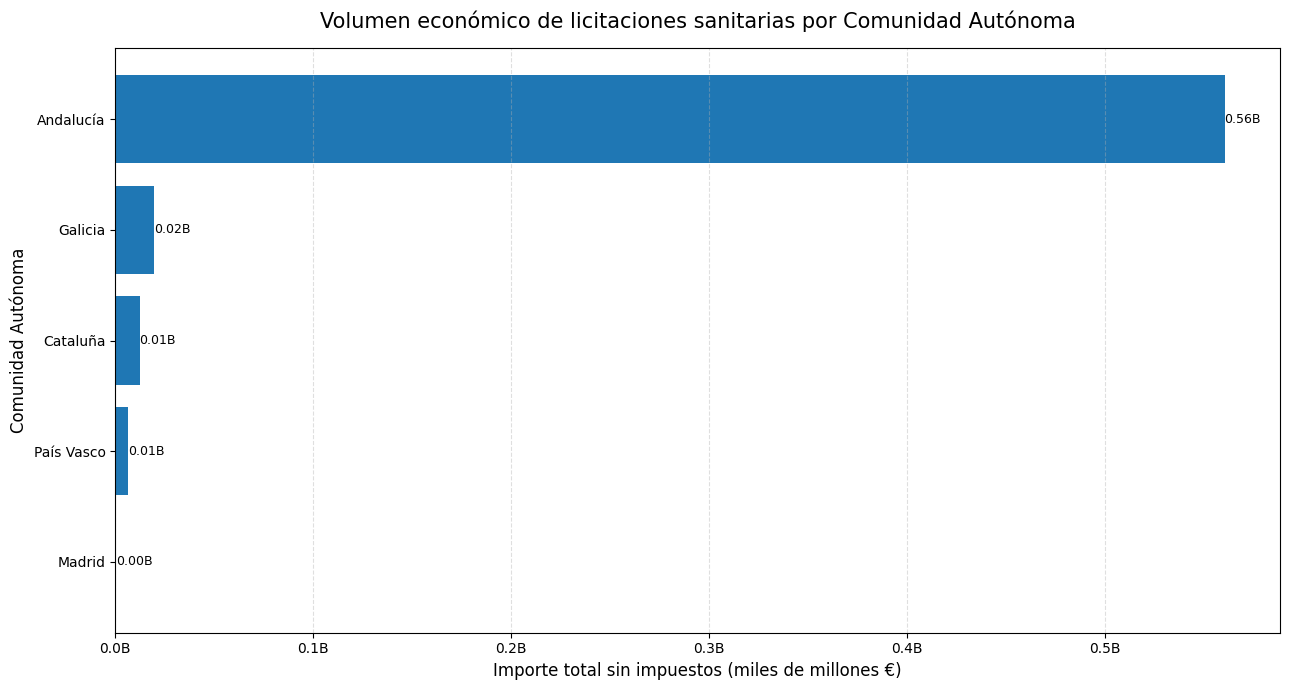

In [218]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 7))

bars = plt.barh(
    importe_ccaa["nombre_region"],
    importe_ccaa["importe_sin_impuestos"]
)

# Formato miles de millones
formatter = FuncFormatter(
    lambda x, pos: f"{x/1e9:.1f}B"
)

plt.gca().xaxis.set_major_formatter(formatter)

# Etiquetas al final de barras
for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width/1e9:.2f}B",
        va="center",
        fontsize=9
    )

plt.title(
    "Volumen económico de licitaciones sanitarias por Comunidad Autónoma",
    fontsize=15,
    pad=15
)

plt.xlabel(
    "Importe total sin impuestos (miles de millones €)",
    fontsize=12
)

plt.ylabel(
    "Comunidad Autónoma",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [219]:
ticket_ccaa = (
    df_ccaa
    .groupby("nombre_region")["importe_sin_impuestos"]
    .mean()
    .reset_index()
    .sort_values(
        "importe_sin_impuestos",
        ascending=True
    )
)

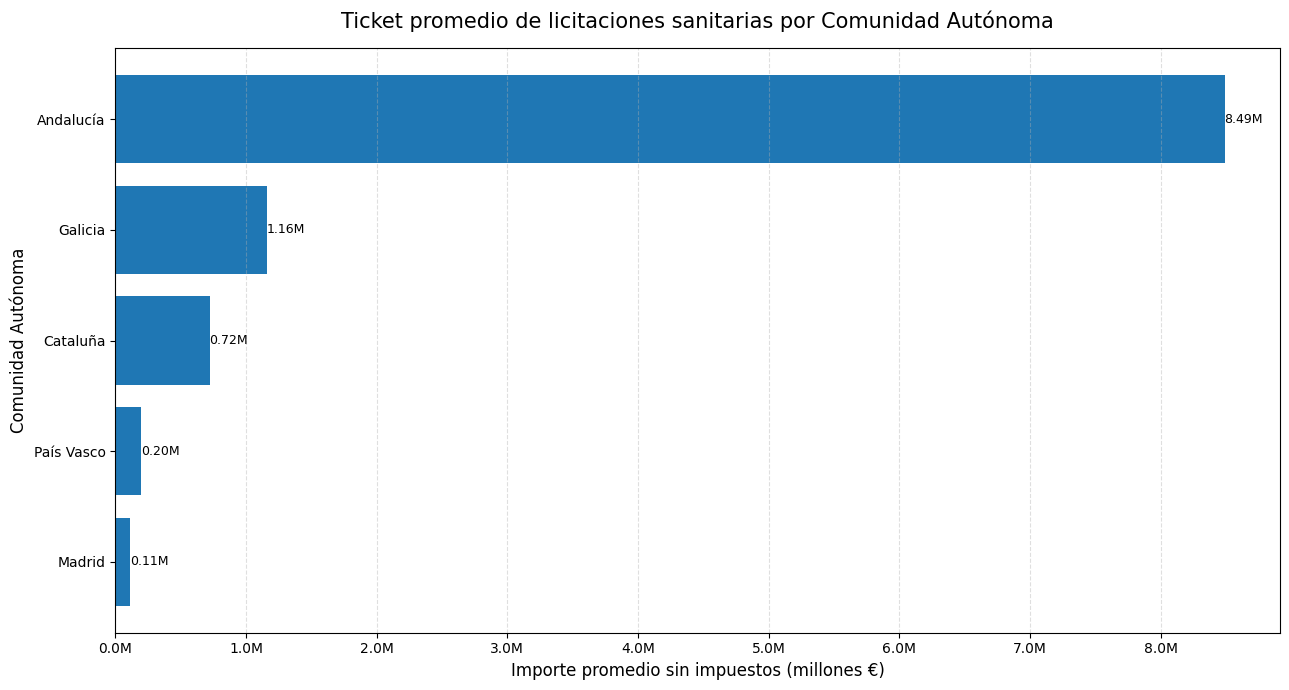

In [220]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

plt.figure(figsize=(13, 7))

bars = plt.barh(
    ticket_ccaa["nombre_region"],
    ticket_ccaa["importe_sin_impuestos"]
)

# Formato millones
formatter = FuncFormatter(
    lambda x, pos: f"{x/1e6:.1f}M"
)

plt.gca().xaxis.set_major_formatter(formatter)

# Etiquetas
for bar in bars:

    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{width/1e6:.2f}M",
        va="center",
        fontsize=9
    )

plt.title(
    "Ticket promedio de licitaciones sanitarias por Comunidad Autónoma",
    fontsize=15,
    pad=15
)

plt.xlabel(
    "Importe promedio sin impuestos (millones €)",
    fontsize=12
)

plt.ylabel(
    "Comunidad Autónoma",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [221]:
n_licitaciones_ccaa = (
    df_ccaa["nombre_region"]
    .value_counts()
    .reset_index()
)

n_licitaciones_ccaa.columns = [
    "nombre_region",
    "n_licitaciones"
]

n_licitaciones_ccaa = n_licitaciones_ccaa.sort_values(
    "n_licitaciones",
    ascending=True
)

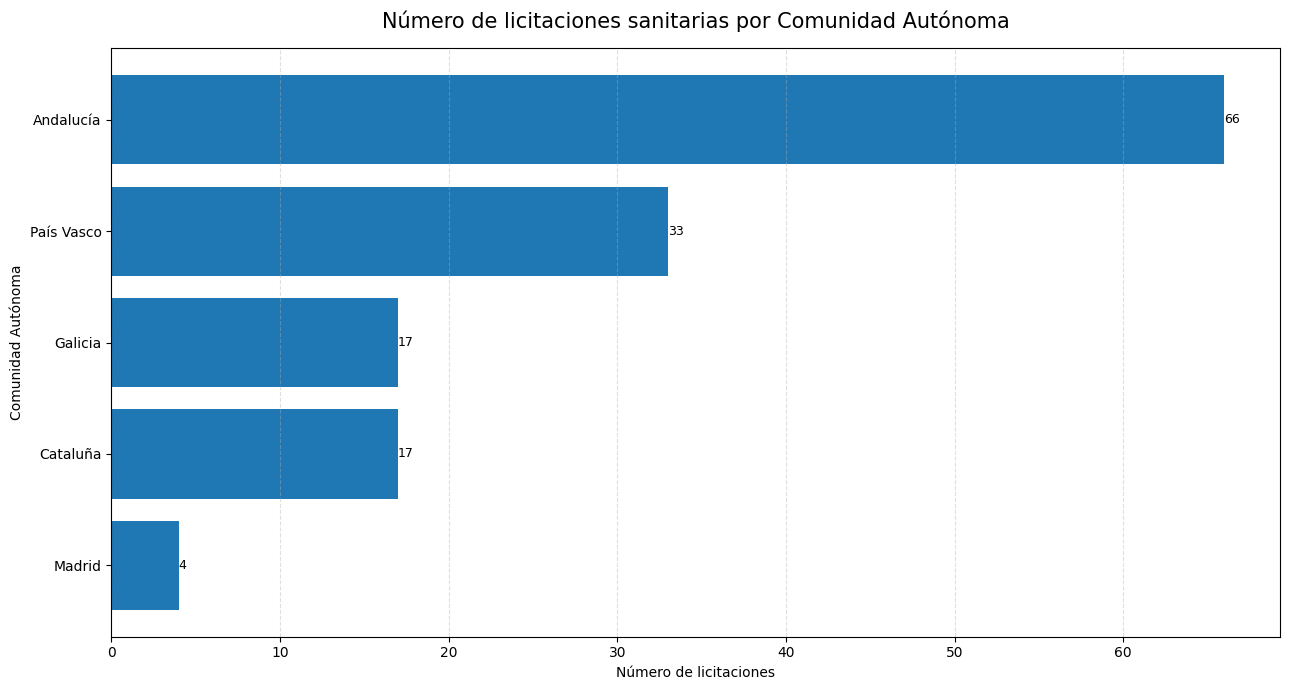

In [222]:
import matplotlib.pyplot as plt

plt.figure(figsize=(13, 7))

bars = plt.barh(
    n_licitaciones_ccaa["nombre_region"],
    n_licitaciones_ccaa["n_licitaciones"]
)

for bar in bars:
    width = bar.get_width()

    plt.text(
        width,
        bar.get_y() + bar.get_height()/2,
        f"{int(width):,}".replace(",", "."),
        va="center",
        fontsize=9
    )

plt.title(
    "Número de licitaciones sanitarias por Comunidad Autónoma",
    fontsize=15,
    pad=15
)

plt.xlabel("Número de licitaciones")
plt.ylabel("Comunidad Autónoma")

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [223]:
resumen_ccaa = (
    df_ccaa
    .groupby("nombre_region")
    .agg(
        n_licitaciones = (
            "licitacion_id",
            "count"
        ),
        ticket_promedio = (
            "importe_sin_impuestos",
            "mean"
        ),
        volumen_total = (
            "importe_sin_impuestos",
            "sum"
        )
    )
    .reset_index()
)

resumen_ccaa

,nombre_region,n_licitaciones,ticket_promedio,volumen_total
0,Andalucía,66,8488321.831667,560229240.89
1,Cataluña,17,721333.867647,12262675.75
2,Galicia,17,1160601.890588,19730232.14
3,Madrid,4,113938.2575,455753.03
4,País Vasco,33,195514.957273,6451993.59


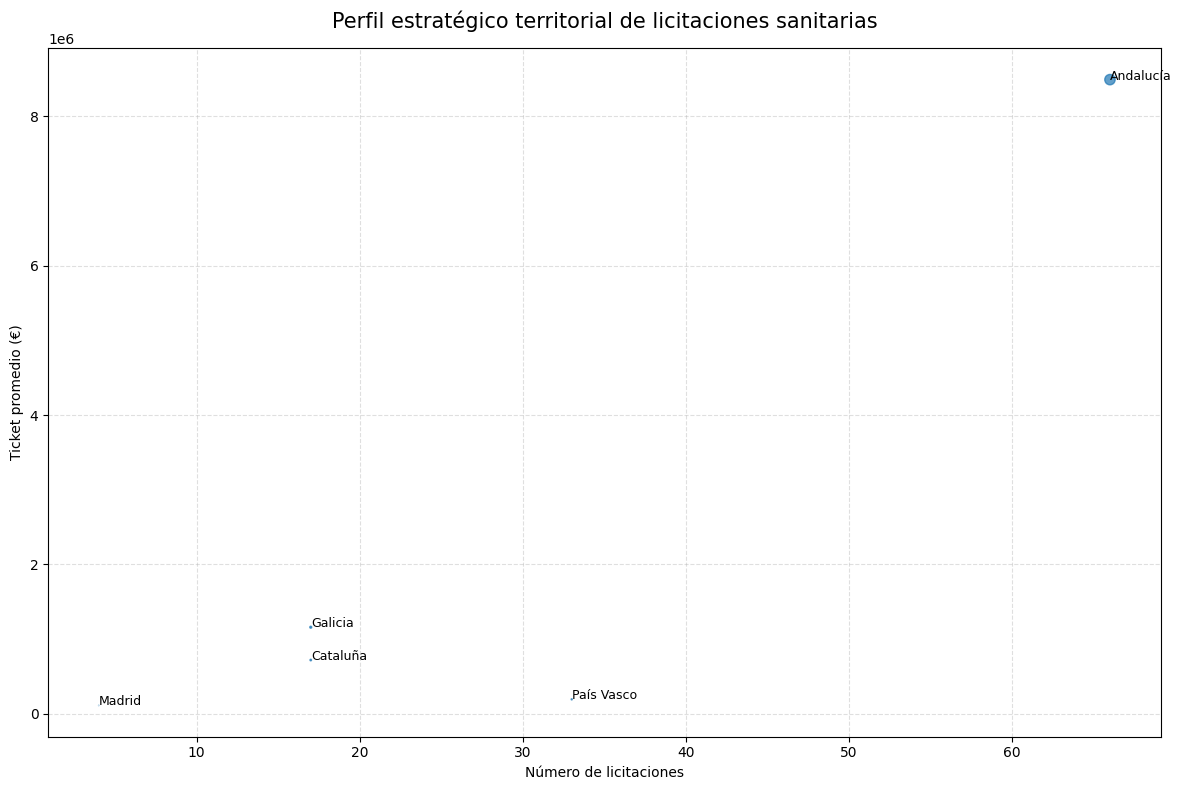

In [224]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

scatter = plt.scatter(
    resumen_ccaa["n_licitaciones"],
    resumen_ccaa["ticket_promedio"],
    s = resumen_ccaa["volumen_total"] / 1e7,
    alpha = 0.7
)

# Etiquetas
for _, row in resumen_ccaa.iterrows():

    x = row["n_licitaciones"]
    y = row["ticket_promedio"]

    # Ajustes manuales para regiones pequeñas
    if row["nombre_region"] in [
        "Cantabria",
        "Extremadura",
        "Comunidad Valenciana",
        "Illes Balears"
    ]:
        x = x + 20
        y = y + 150000

    plt.text(
        x,
        y,
        row["nombre_region"],
        fontsize=9
    )

plt.title(
    "Perfil estratégico territorial de licitaciones sanitarias",
    fontsize=15,
    pad=15
)

plt.xlabel("Número de licitaciones")
plt.ylabel("Ticket promedio (€)")

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()

plt.show()

In [225]:
import requests
import json

url_geojson = "https://raw.githubusercontent.com/codeforgermany/click_that_hood/main/public/data/spain-communities.geojson"

geojson_ccaa = requests.get(url_geojson).json()

geojson_ccaa["features"][0]["properties"]

{'cod_ccaa': '07',
 'noml_ccaa': 'COMUNIDAD DE CASTILLA Y LEON',
 'name': 'Castilla-Leon',
 'cartodb_id': 7,
 'created_at': '2014-09-30T00:00:00Z',
 'updated_at': '2014-12-25T02:07:41Z'}

In [226]:
resumen_ccaa["nombre_region"].unique()

array(['Andalucía', 'Cataluña', 'Galicia', 'Madrid', 'País Vasco'],
      dtype=object)

In [227]:
geojson_df = pd.DataFrame([
    feature["properties"]
    for feature in geojson_ccaa["features"]
])

geojson_df.head()

,cod_ccaa,noml_ccaa,name,cartodb_id,created_at,updated_at
0,07,COMUNIDAD DE CASTILLA Y LEON,Castilla-Leon,7,2014-09-30T00:00:00Z,2014-12-25T02:07:41Z
1,09,COMUNIDAD AUTONOMA DE CATALUÑA,Cataluña,8,2014-09-30T00:00:00Z,2014-12-25T02:07:41Z
2,18,CIUDAD DE CEUTA,Ceuta,9,2014-09-30T00:00:00Z,2014-12-25T02:07:41Z
3,14,COMUNIDAD AUTONOMA DE LA REGION DE MURCI,Murcia,15,2014-09-30T00:00:00Z,2014-12-25T02:07:41Z
4,17,COMUNIDAD AUTONOMA DE LA RIOJA,La Rioja,12,2014-09-30T00:00:00Z,2014-12-25T02:07:41Z


In [228]:
geojson_df["name"].sort_values().unique()

array(['Andalucia', 'Aragon', 'Asturias', 'Baleares', 'Canarias',
       'Cantabria', 'Castilla-La Mancha', 'Castilla-Leon', 'Cataluña',
       'Ceuta', 'Extremadura', 'Galicia', 'La Rioja', 'Madrid', 'Melilla',
       'Murcia', 'Navarra', 'Pais Vasco', 'Valencia'], dtype=object)

In [229]:
mapa_nombres_ccaa = {
    "Castilla y León": "Castilla-Leon",
    "Comunidad Valenciana": "Valencia",
    "Illes Balears": "Baleares",
    "Principado de Asturias": "Asturias",
    "Andalucía": "Andalucia",
    "País Vasco": "Pais Vasco"

}

In [230]:
resumen_ccaa["nombre_geojson"] = (
    resumen_ccaa["nombre_region"]
    .replace(mapa_nombres_ccaa)
)

In [231]:
set(resumen_ccaa["nombre_geojson"]) - set(geojson_df["name"])

set()

In [232]:
import plotly.express as px

fig = px.choropleth(
    resumen_ccaa,
    geojson=geojson_ccaa,
    locations="nombre_geojson",
    featureidkey="properties.name",
    color="volumen_total",
    hover_name="nombre_region",
    hover_data={
        "volumen_total": ":,.0f",
        "n_licitaciones": ":,",
        "ticket_promedio": ":,.0f",
        "nombre_geojson": False
    },
    title="Volumen económico de licitaciones sanitarias por Comunidad Autónoma"
)

fig.update_traces(
    marker_line_width=1,
    marker_line_color="white"
)

fig.update_geos(
    fitbounds="locations",
    visible=True,
    showcountries=True,
    countrycolor="black",
    showsubunits=True,
    subunitcolor="black",
    showland=True,
    landcolor="lightgray",
    showocean=False,
    showlakes=False
)

fig.update_layout(
    margin={"r":0, "t":50, "l":0, "b":0}
)

fig.show()

El análisis territorial evidencia que la distribución geográfica de las oportunidades compatibles con los servicios de Clínica Los Tilos no es homogénea. Andalucía concentra simultáneamente el mayor número de licitaciones y el mayor volumen económico acumulado dentro de la muestra analizada, posicionándose como el territorio de mayor relevancia estratégica. Por su parte, comunidades como País Vasco, Galicia y Cataluña presentan niveles de actividad inferiores, aunque mantienen una presencia significativa dentro del mercado sanitario público.

Los resultados también muestran que la frecuencia de licitación y el volumen económico no siempre evolucionan de forma conjunta. Mientras algunas comunidades destacan por generar un elevado número de oportunidades, otras concentran contratos de mayor valor económico medio. Este comportamiento sugiere que la priorización territorial no debería basarse exclusivamente en la cantidad de licitaciones disponibles, sino también en el potencial económico asociado a cada mercado regional.

Adicionalmente, las diferencias observadas entre comunidades autónomas ponen de manifiesto la existencia de patrones territoriales diferenciados en la contratación sanitaria, lo que refuerza la importancia de incorporar la dimensión geográfica dentro de los procesos de análisis y seguimiento de oportunidades.

Desde la perspectiva del proyecto, estos hallazgos permiten identificar territorios con mayor atractivo estratégico para futuras acciones de monitorización y análisis, facilitando la construcción de mecanismos de priorización que integren simultáneamente criterios de frecuencia, volumen económico y relevancia institucional. Esta información constituye un insumo relevante para el diseño del sistema de scoring propuesto, orientado a apoyar la identificación y selección de licitaciones con mayor potencial para Clínica Los Tilos.


### Clinica los TIlos

In [235]:
df_eda[
    df_eda["adjudicatario"]
    .astype("string")
    .str.upper()
    .str.contains("TILOS", na=False)
][["licitacion_id", "titulo", "adjudicatario", "adjudicatario_nif", "importe_sin_impuestos"]]

,licitacion_id,titulo,adjudicatario,adjudicatario_nif,importe_sin_impuestos
12584,f14496dfcc8d5128,Contratación del servicio de Diagnóstico por l...,Ver detalle de la adjudicación (multi-lote; in...,No informado,631666.9
12585,fd6b2f590c512031,Servicio de asistencia sanitaria especializada...,"TILOSALUD, S.A.",A40213217,16375.0
12586,1967eade2fccb129,Contratación del servicio de Asistencia Sanita...,Ver detalle de la adjudicación (multi-lote; in...,No informado,270639.6
12587,3fc7125e9f8a3d95,Realización de procedimientos diagnósticos (ul...,"TILOSALUD, S.A.",A40213217,172000.0
12588,ddec9f7e2e9944dc,Servicio de reconocimientos médicos personal a...,"TILOSALUD, S.A.; ASPY PREVENCION.S.L.U.",A40213217; B98844574,15975.0


In [234]:
df_tilos.shape[0]

0

In [236]:
df_tilos = df_eda[
    df_eda["adjudicatario"]
    .astype("string")
    .str.upper()
    .str.contains("TILOSALUD", na=False)
].copy()

In [238]:
df_tilos.head()

,licitacion_id,titulo,detail_url,updated,expediente,tipo_contrato_codigo,lugar_ejecucion_codigo,cpv_codes,organo_contratacion,estado_codigo,...,tipo_contrato,url,cpv_descripcion,cpv_nivel,importe_log,tamano_licitacion,year_month,year_week,codigo_nuts,nombre_region
12584,f14496dfcc8d5128,Contratación del servicio de Diagnóstico por l...,https://contrataciondelestado.es/wps/poc?idEvl...,NaT,LICT/99/139/2020/0123,Servicios,None,85100000,,RES,...,Servicios,https://contrataciondelestado.es/wps/poc?idEvl...,Servicios de salud,Grupo,13.356119,Muy grande,NaT,NaT,NaN,NaN
12585,fd6b2f590c512031,Servicio de asistencia sanitaria especializada...,https://contrataciondelestado.es/wps/poc?idEvl...,NaT,CS-2022/4002/0004,Servicios,None,85100000,,ADJ,...,Servicios,https://contrataciondelestado.es/wps/poc?idEvl...,Servicios de salud,Grupo,9.703572,Grande,NaT,NaT,NaN,NaN
12586,1967eade2fccb129,Contratación del servicio de Asistencia Sanita...,https://contrataciondelestado.es/wps/portal/%2...,NaT,LICT/99/139/2022/0206,Servicios,None,85100000,,RES,...,Servicios,https://contrataciondelestado.es/wps/portal/%2...,Servicios de salud,Grupo,12.508547,Muy grande,NaT,NaT,NaN,NaN
12587,3fc7125e9f8a3d95,Realización de procedimientos diagnósticos (ul...,https://contrataciondelestado.es/wps/poc?uri=d...,NaT,6301-631-1-2025-15479,Servicios,None,85121200,,RES,...,Servicios,https://contrataciondelestado.es/wps/poc?uri=d...,Servicios de médicos especialistas,Detalle,12.055256,Muy grande,NaT,NaT,NaN,NaN
12588,ddec9f7e2e9944dc,Servicio de reconocimientos médicos personal a...,https://contrataciondelestado.es/FileSystem/se...,NaT,40/VC-184/25,Servicios,None,85121100;85121210;85121240;85121292,,RES,...,Servicios,https://contrataciondelestado.es/FileSystem/se...,Servicios de médicos de medicina general; Serv...,Detalle,9.678843,Grande,NaT,NaT,NaN,NaN


In [ ]:
print("Número de adjudicaciones:", len(df_tilos))
print("Importe total adjudicado:", df_tilos["importe_sin_impuestos"].sum())
print("Mayor adjudicación:", df_tilos["importe_sin_impuestos"].max())
print("Menor adjudicación:", df_tilos["importe_sin_impuestos"].min())

Número de adjudicaciones: 5
Importe total adjudicado: 1106656.5
Importe promedio: 221331.3
Mayor adjudicación: 631666.9
Menor adjudicación: 15975.0


In [240]:
df_tilos[
    [
        "fecha_publicacion",
        "titulo",
        "organo_contratacion",
        "nombre_region",
        "importe_sin_impuestos"
    ]
].sort_values(
    "importe_sin_impuestos",
    ascending=False
)

,fecha_publicacion,titulo,organo_contratacion,nombre_region,importe_sin_impuestos
12584,NaT,Contratación del servicio de Diagnóstico por l...,,NaN,631666.9
12586,NaT,Contratación del servicio de Asistencia Sanita...,,NaN,270639.6
12587,NaT,Realización de procedimientos diagnósticos (ul...,,NaN,172000.0
12585,NaT,Servicio de asistencia sanitaria especializada...,,NaN,16375.0
12588,NaT,Servicio de reconocimientos médicos personal a...,,NaN,15975.0


In [241]:
df_tilos[
    [
        "cpv_descripcion",
        "importe_sin_impuestos"
    ]
].sort_values(
    "importe_sin_impuestos",
    ascending=False
)

,cpv_descripcion,importe_sin_impuestos
12584,Servicios de salud,631666.9
12586,Servicios de salud,270639.6
12587,Servicios de médicos especialistas,172000.0
12585,Servicios de salud,16375.0
12588,Servicios de médicos de medicina general; Serv...,15975.0


In [243]:
df_tilos.groupby("organo_contratacion").agg(
    adjudicaciones=("licitacion_id","count"),
    importe_total=("importe_sin_impuestos","sum")
).sort_values(
    "importe_total",
    ascending=False
)

,adjudicaciones,importe_total
organo_contratacion,,
,5,1106656.5


In [244]:
pd.set_option("display.max_colwidth", None)

df_tilos[
    [
        "titulo",
        "cpv_descripcion",
        "importe_sin_impuestos"
    ]
].sort_values(
    "importe_sin_impuestos",
    ascending=False
)

,titulo,cpv_descripcion,importe_sin_impuestos
12584,Contratación del servicio de Diagnóstico por la imagen en Andalucía y Castilla y León para FREMAP,Servicios de salud,631666.9
12586,Contratación del servicio de Asistencia Sanitaria Especializada en Castilla y León y Cantabria para FREMAP,Servicios de salud,270639.6
12587,Realización de procedimientos diagnósticos (ultrasonidos e informes de imagen diagnóstica) para SACYL Segovia,Servicios de médicos especialistas,172000.0
12585,Servicio de asistencia sanitaria especializada en pruebas de diagnóstico por imagen en Segovia,Servicios de salud,16375.0
12588,Servicio de reconocimientos médicos personal adscrito al INSS,Servicios de médicos de medicina general; Servicios de otorrinolaringología o audiología; Servicios ginecológicos u obstétricos; Servicios urológicos,15975.0


## Análisis histórico de adjudicaciones identificadas para Clínica Los Tilos (TILOSALUD, S.A.)

Con el objetivo de complementar el análisis general del mercado sanitario y aportar evidencia sobre la experiencia previa de la organización en contratación pública, se realizó una búsqueda específica de adjudicaciones asociadas a **TILOSALUD, S.A.** dentro de la base de datos consolidada de licitaciones sanitarias.

La identificación se efectuó mediante el campo de adjudicatario, localizando aquellos registros en los que la entidad adjudicataria correspondía a TILOSALUD, S.A. Como resultado se identificaron **cinco adjudicaciones** asociadas a la organización.

### Resumen general de adjudicaciones identificadas

| Indicador                              |          Valor |
| -------------------------------------- | -------------: |
| Número de adjudicaciones identificadas |              5 |
| Importe total adjudicado               | 1.106.656,50 € |
| Importe promedio por adjudicación      |   221.331,30 € |
| Mayor adjudicación identificada        |   631.666,90 € |
| Menor adjudicación identificada        |    15.975,00 € |

Los resultados muestran que la actividad contractual identificada se concentra en un número reducido de adjudicaciones, aunque con importes relevantes para una entidad sanitaria especializada. El valor medio de los contratos supera los 220.000 euros, reflejando una participación en procesos de contratación de tamaño medio y alto dentro del ámbito sanitario.

---

## Detalle de las adjudicaciones identificadas

| Servicio adjudicado                                                                                           | Organismo       | Importe (€) |
| ------------------------------------------------------------------------------------------------------------- | --------------- | ----------: |
| Contratación del servicio de Diagnóstico por la Imagen en Andalucía y Castilla y León para FREMAP             | FREMAP          |  631.666,90 |
| Contratación del servicio de Asistencia Sanitaria Especializada en Castilla y León y Cantabria para FREMAP    | FREMAP          |  270.639,60 |
| Realización de procedimientos diagnósticos (ultrasonidos e informes de imagen diagnóstica) para SACYL Segovia | SACYL           |  172.000,00 |
| Servicio de asistencia sanitaria especializada en pruebas de diagnóstico por imagen en Segovia                | No identificado |   16.375,00 |
| Servicio de reconocimientos médicos para personal adscrito al INSS                                            | INSS            |   15.975,00 |

La revisión individual de los contratos permite observar que la actividad contractual de Clínica Los Tilos se encuentra estrechamente vinculada a la prestación de servicios asistenciales especializados y procedimientos diagnósticos, especialmente aquellos relacionados con el diagnóstico por imagen.

---

## Principales líneas de servicio adjudicadas

El análisis de las descripciones CPV y de los títulos de las adjudicaciones permite identificar tres líneas principales de actividad:

### Diagnóstico por imagen

Esta categoría concentra la mayor parte del volumen económico identificado y aparece de forma recurrente en varias adjudicaciones.

Entre los servicios adjudicados se encuentran:

* Diagnóstico por imagen para FREMAP.
* Pruebas diagnósticas mediante imagen médica.
* Procedimientos de ultrasonido e interpretación diagnóstica.

La recurrencia de este tipo de contratos sugiere que la capacidad diagnóstica constituye una de las principales fortalezas competitivas de la organización dentro del ámbito de la contratación pública sanitaria.

### Asistencia sanitaria especializada

La segunda línea de actividad corresponde a servicios de asistencia sanitaria especializada, especialmente asociados a la atención de pacientes derivados por organismos públicos y mutuas colaboradoras.

Las adjudicaciones identificadas indican experiencia en la prestación de servicios médicos especializados fuera del entorno hospitalario tradicional, aspecto especialmente relevante para entidades sanitarias privadas que participan en procesos de externalización asistencial.

### Reconocimientos médicos

Aunque representa una proporción económica menor dentro del conjunto de adjudicaciones encontradas, también se identificaron contratos relacionados con reconocimientos médicos para personal adscrito a organismos públicos.

Esta línea evidencia una diversificación moderada de los servicios ofertados por la organización.

---

## Análisis de la concentración económica

Uno de los hallazgos más relevantes corresponde a la distribución del volumen económico adjudicado.

Las dos mayores adjudicaciones identificadas corresponden a contratos con FREMAP:

| Contrato                                       |    Importe (€) |
| ---------------------------------------------- | -------------: |
| Diagnóstico por imagen para FREMAP             |     631.666,90 |
| Asistencia sanitaria especializada para FREMAP |     270.639,60 |
| **Total FREMAP**                               | **902.306,50** |

Estas dos adjudicaciones representan aproximadamente el **81,5% del importe total adjudicado identificado** dentro de la muestra analizada.

Este resultado evidencia una elevada concentración económica en un número reducido de contratos y pone de manifiesto la relevancia de FREMAP como cliente institucional para la organización.

---

## Perfil institucional de los organismos contratantes

Los organismos identificados pertenecen a distintos ámbitos de la administración sanitaria y asistencial española:

### FREMAP

Mutua colaboradora con la Seguridad Social especializada en la gestión de contingencias profesionales y asistencia sanitaria.

Las adjudicaciones identificadas muestran una relación contractual relevante entre FREMAP y TILOSALUD, especialmente en servicios de diagnóstico y asistencia especializada.

### Servicio de Salud de Castilla y León (SACYL)

Se identificó una adjudicación vinculada a procedimientos diagnósticos para la provincia de Segovia, lo que evidencia la capacidad de la organización para participar en procesos promovidos directamente por el sistema público de salud.

### Instituto Nacional de la Seguridad Social (INSS)

La presencia de una adjudicación relacionada con reconocimientos médicos demuestra experiencia en servicios de apoyo sanitario vinculados a organismos estatales.

---

## Implicaciones para el sistema de scoring propuesto

Desde la perspectiva metodológica del proyecto, estos resultados aportan evidencia objetiva sobre la experiencia previa de Clínica Los Tilos en contratación pública sanitaria.

Las adjudicaciones identificadas permiten concluir que la organización posee experiencia demostrable en:

* Servicios de diagnóstico por imagen.
* Procedimientos diagnósticos especializados.
* Asistencia sanitaria especializada.
* Reconocimientos médicos para organismos públicos.

Asimismo, los contratos identificados muestran relaciones previas con organismos de elevada relevancia institucional como FREMAP, SACYL e INSS.

Esta información resulta especialmente útil para la construcción de la dimensión de **experiencia previa** dentro del sistema de scoring propuesto, ya que permite incorporar evidencia histórica real sobre la participación y éxito de la organización en procesos de contratación pública sanitaria.

En consecuencia, las adjudicaciones históricas identificadas constituyen un activo estratégico para la organización y una fuente de información relevante para priorizar futuras oportunidades de licitación con características similares en términos de servicio, cliente institucional y alcance asistencial.
